In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from lmfit.models import GaussianModel, VoigtModel, ConstantModel
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
from scipy.interpolate import UnivariateSpline
from pathlib import Path

#import numpy.polynomial.polynomial as poly
#from numpy.polynomial import Polynomial
#import scipy.constants as const
#from matplotlib.animation import FuncAnimation, PillowWriter
#from astropy.time import Time
#from IPython.display import HTML

<h2 style="color: #e19edc;"> Antares</h2>
<h3 style="color: #e19edc;"> Espectros que debían cambiar pixel por longitud de onda</h3>

In [2]:
# Rutas de Julio, Agosto y Septiembre del 2025 y 2026

ruta_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 6563 julio 22.xlsx"

ruta_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares agosto 26 orden 1.xlsx"

ruta_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares septiembre 6 orden 1.xlsx"

#Datos de Julio, Agosto y Septiembre del 2025 y 2026

antares_julio = pd.read_excel(ruta_julio, sheet_name="ster 6563 normaliz", usecols=[0,3], header=None, names =["pixel", "flujo normalizado"])

antares_agosto = pd.read_excel(ruta_agosto, sheet_name="ster orden1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])

antares_septiembre = pd.read_excel(ruta_septiembre, sheet_name="ster orden 1", usecols=[0, 3], header=None, names =["pixel", "flujo normalizado"])


<h4 style="color: #e19edc;"> Visualización del perfil de la línea H<sub>&alpha;</sub> en diferentes meses</h4>

In [3]:
pixeles_julio = antares_julio["pixel"].values
flujo_julio = antares_julio["flujo normalizado"].values
longitudes_observadas_julio = -3.035260607578e-13 * pixeles_julio**4 + 8.715422792701e-10 * pixeles_julio**3 - 0.0000007942095333894*pixeles_julio**2 + 0.09284696077816 * pixeles_julio + 6506.688414868

<h4 style="color: #e19edc;"> Julio</h4>

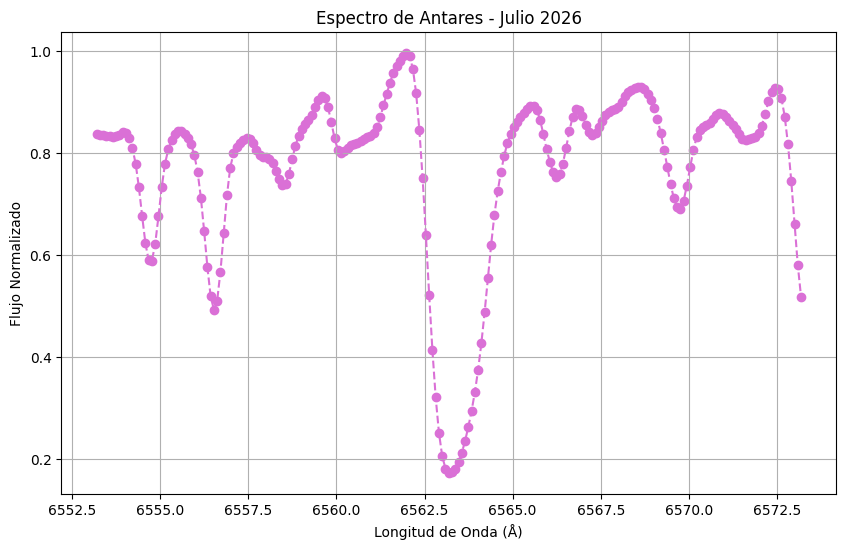

In [4]:
centro_julio = 6563.18533

indices_cercanos_julio = np.where((longitudes_observadas_julio >= centro_julio - 10) & (longitudes_observadas_julio <= centro_julio + 10))[0]


datos_cercanos_julio = pd.DataFrame({'Longitud onda': longitudes_observadas_julio[indices_cercanos_julio], 'Flujo Normalizado': flujo_julio[indices_cercanos_julio]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio["Longitud onda"], datos_cercanos_julio["Flujo Normalizado"], '--', color = "orchid")
plt.scatter(datos_cercanos_julio["Longitud onda"], datos_cercanos_julio["Flujo Normalizado"], color = "orchid")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Julio 2026")
plt.grid(True)
plt.show()


<h4 style="color: #e19edc;"> Agosto </h4>

In [5]:
pixeles_agosto = antares_agosto["pixel"].values
flujo_agosto = antares_agosto["flujo normalizado"].values
longitudes_observadas_agosto = 1.39394098683175e-18 * pixeles_agosto**6 - 6.58044383788171E-15*pixeles_agosto**5 + 1.16354508506345E-11*pixeles_agosto**4 - 9.29864698195214E-09*pixeles_agosto**3 + 3.02469198127472E-06*pixeles_agosto**2 + 0.0924365570558958*pixeles_agosto + 6492.49282015586

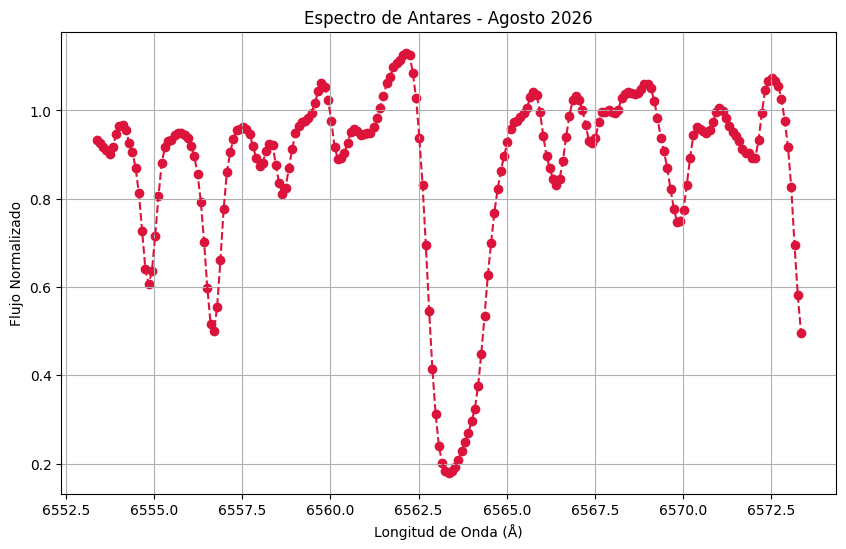

In [6]:
centro_agosto = 6563.35423

indices_cercanos_agosto = np.where((longitudes_observadas_agosto >= centro_agosto - 10) & (longitudes_observadas_agosto <= centro_agosto + 10))[0]


datos_cercanos_agosto = pd.DataFrame({'Longitud onda': longitudes_observadas_agosto[indices_cercanos_agosto], 'Flujo Normalizado': flujo_agosto[indices_cercanos_agosto]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_agosto["Longitud onda"], datos_cercanos_agosto["Flujo Normalizado"], '--', color = "crimson")
plt.scatter(datos_cercanos_agosto["Longitud onda"], datos_cercanos_agosto["Flujo Normalizado"], color = "crimson")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Agosto 2026")
plt.grid(True)
plt.show()

<h4 style="color: #e19edc;"> Septiembre</h4>

In [7]:
pixeles_septiembre = antares_septiembre["pixel"].values
flujo_septiembre = antares_septiembre["flujo normalizado"].values
longitudes_observadas_septiembre = -1.179402526298E-13*pixeles_septiembre**4 + 4.020234124929E-10*pixeles_septiembre**3 - 0.0000004743246209058*pixeles_septiembre**2 + 0.09282817058921*pixeles_septiembre + 6490.328062797

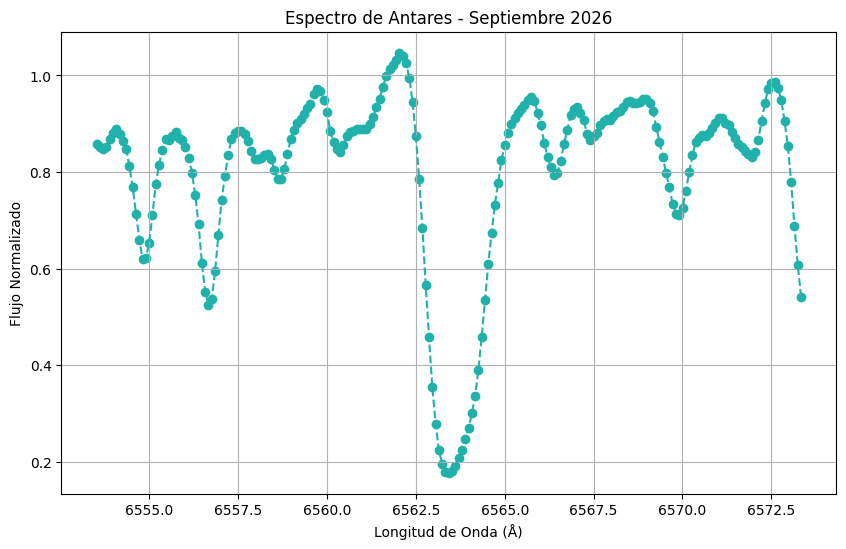

In [8]:
centro_septiembre = 6563.42597

indices_cercanos_septiembre = np.where((longitudes_observadas_septiembre >= centro_septiembre - 10) & (longitudes_observadas_septiembre <= centro_septiembre + 10))[0]


datos_cercanos_septiembre = pd.DataFrame({'Longitud onda': longitudes_observadas_septiembre[indices_cercanos_septiembre], 'Flujo Normalizado': flujo_septiembre[indices_cercanos_septiembre]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_septiembre["Longitud onda"], datos_cercanos_septiembre["Flujo Normalizado"], '--', color = "lightseagreen")
plt.scatter(datos_cercanos_septiembre["Longitud onda"], datos_cercanos_septiembre["Flujo Normalizado"], color = "lightseagreen")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares - Septiembre 2026")
plt.grid(True)
plt.show()

<h3 style="color: #e19edc;"> Espectros que viene con longitud de onda y flujo</h3>

<h5 style="color: #e19edc;"> 2024</h5>

In [9]:
#Rutas Julio, Agosto, Septiembre y Octubre

ruta_11_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 julio 11.xlsx"
ruta_22_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 julio 22.xlsx"
ruta_16_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 agosto 16.xlsx"
ruta_26_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 agosto 26.xlsx"
ruta_06_septiembre= r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 septiembre 6.xlsx"
ruta_19_septiembre= r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 septiembre 19.xlsx"
ruta_24_septiembre= r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 septiembre 24.xlsx"
ruta_01_octubre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 octubre 1.xlsx"
ruta_11_octubre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 octubre 11.xlsx"
ruta_17_octubre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 octubre 17.xlsx"
ruta_18_octubre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 octubre 18.xlsx"
ruta_24_octubre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2024\2024 octubre 24.xlsx"

In [10]:
antares_11_julio = pd.read_excel(ruta_11_julio, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_22_julio = pd.read_excel(ruta_22_julio, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_16_agosto = pd.read_excel(ruta_16_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_26_agosto = pd.read_excel(ruta_26_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_06_septiembre = pd.read_excel(ruta_06_septiembre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_19_septiembre = pd.read_excel(ruta_19_septiembre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_24_septiembre = pd.read_excel(ruta_24_septiembre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_01_octubre = pd.read_excel(ruta_01_octubre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_11_octubre = pd.read_excel(ruta_11_octubre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo"])
antares_17_octubre = pd.read_excel(ruta_17_octubre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo"])
antares_18_octubre = pd.read_excel(ruta_18_octubre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_24_octubre = pd.read_excel(ruta_24_octubre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])

<h5 style="color: #e19edc;"> 2025 y 2026</h5>

In [11]:
#Rutas Julio, Agosto y Septiembre

ruta_24_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 24 julio 2026.xlsx"
ruta_27_julio = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 27 julio 2026.xlsx"
ruta_06_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 6 agosto 2026.xlsx"
ruta_10_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 10 agosto 2026.xlsx"
ruta_13_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 13 agosto 2026.xlsx"
ruta_28_agosto = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 28 agosto 2026.xlsx"
ruta_07_septiembre = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Espectros de Antares\2025 y 2026\Antares 7 septiembre 2026.xlsx"

In [12]:
#Datos de Julio, Agosto y Septiembre

antares_24_julio = pd.read_excel(ruta_24_julio, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_27_julio = pd.read_excel(ruta_27_julio, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_06_agosto = pd.read_excel(ruta_06_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_10_agosto = pd.read_excel(ruta_10_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_13_agosto = pd.read_excel(ruta_13_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo Normalizado"])
antares_28_agosto = pd.read_excel(ruta_28_agosto, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo"])
antares_07_septiembre = pd.read_excel(ruta_07_septiembre, sheet_name = "Sheet1", usecols = [0,1],header = None, names = ["Longitud onda", "Flujo"])

<h4 style="color: #e19edc;"> Parámetros de la normalización con el método Sigma - Clipping</h4>
<h5 style="color: #e19edc;"> Normalización de espectros</h5>

In [13]:
espectros_por_normalizar = {
    "antares_11_octubre": antares_11_octubre,
    "antares_17_octubre": antares_17_octubre,
    "antares_28_agosto": antares_28_agosto,
    "antares_07_septiembre": antares_07_septiembre
}

In [14]:
guardar_graficos = True   
carpeta_graficos = "./Graficas 2024, 2025 y 2026/Espectros_normalizados"  
 
col_longitud_onda = "Longitud onda"
col_flujo = "Flujo"
 
grado_polinomio= 2     
N_iteraciones = 10
sigma_corte = 2.0

In [15]:
def ajustar_continuo(longitud_onda, flujo, grado, n_iter, sigma):

    longitud_onda = np.asarray(longitud_onda, dtype=float)
    flujo = np.asarray(flujo, dtype=float)
 
    mascara = np.ones_like(flujo, dtype=bool)
 
    for _ in range(n_iter):
        coef = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
        continuo_iter = np.polyval(coef, longitud_onda)
 
        residuo = flujo - continuo_iter
        
        mediana = np.median(residuo[mascara])
        mad = np.median(np.abs(residuo[mascara] - mediana))
        mad_std = mad * 1.4826

        umbral_superior = mediana + sigma * mad_std
        umbral_inferior = mediana - sigma * mad_std
        nueva_mascara = (residuo > umbral_inferior) & (residuo < umbral_superior)
 
        if nueva_mascara.sum() < grado + 2:
            break

        if np.array_equal(nueva_mascara, mascara):
            break
 
        mascara = nueva_mascara
 
    coef_final = np.polyfit(longitud_onda[mascara], flujo[mascara], deg=grado)
    continuo = np.polyval(coef_final, longitud_onda)
 
    return continuo, mascara


Procesando: antares_11_octubre
  Puntos totales: 180
  Puntos excluidos: 64
  -> Gráfico guardado: Graficas 2024, 2025 y 2026\Espectros_normalizados\antares_11_octubre_control.png


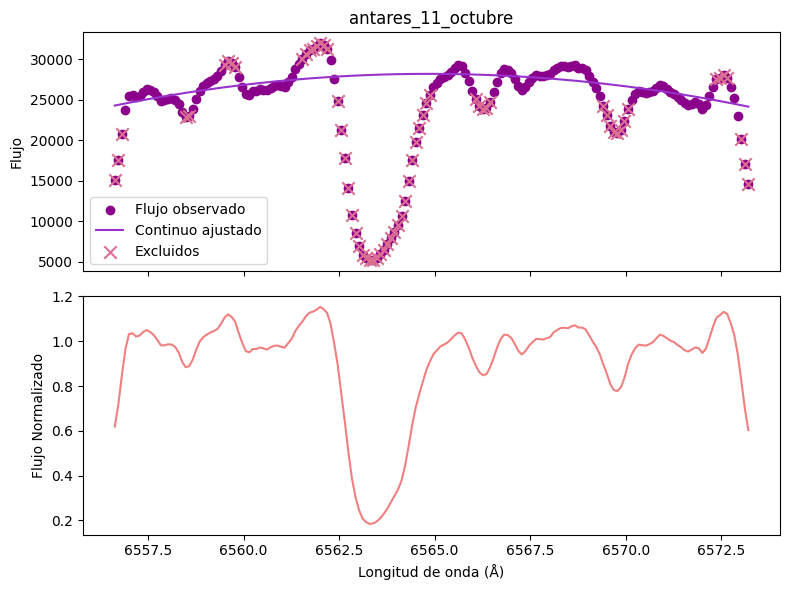


Procesando: antares_17_octubre
  Puntos totales: 180
  Puntos excluidos: 67
  -> Gráfico guardado: Graficas 2024, 2025 y 2026\Espectros_normalizados\antares_17_octubre_control.png


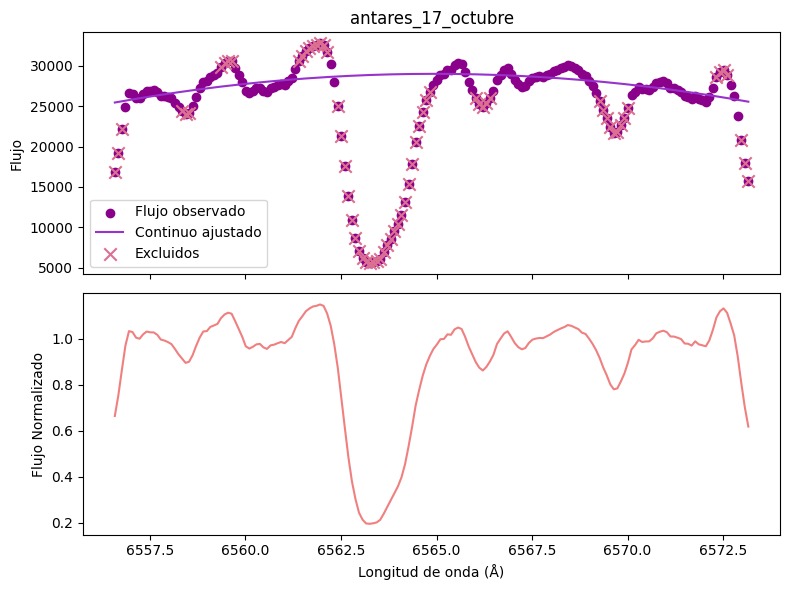


Procesando: antares_28_agosto
  Puntos totales: 180
  Puntos excluidos: 49
  -> Gráfico guardado: Graficas 2024, 2025 y 2026\Espectros_normalizados\antares_28_agosto_control.png


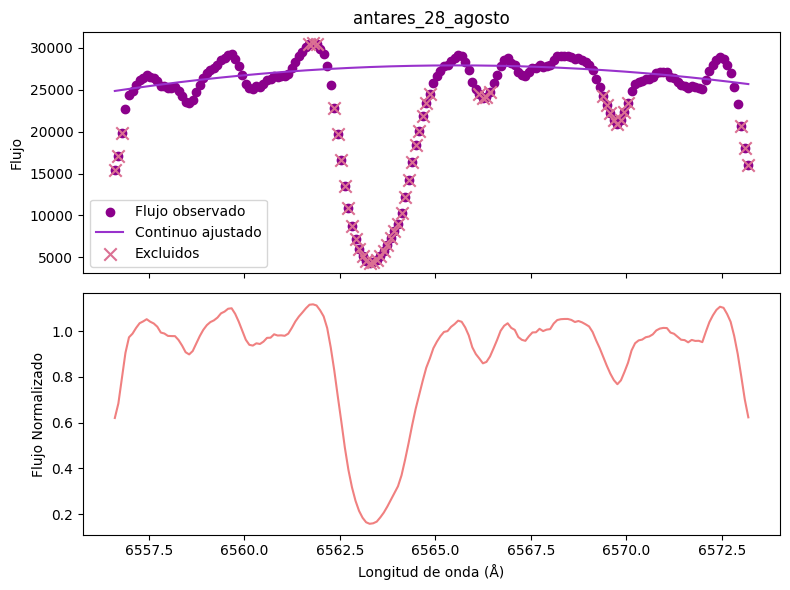


Procesando: antares_07_septiembre
  Puntos totales: 180
  Puntos excluidos: 49
  -> Gráfico guardado: Graficas 2024, 2025 y 2026\Espectros_normalizados\antares_07_septiembre_control.png


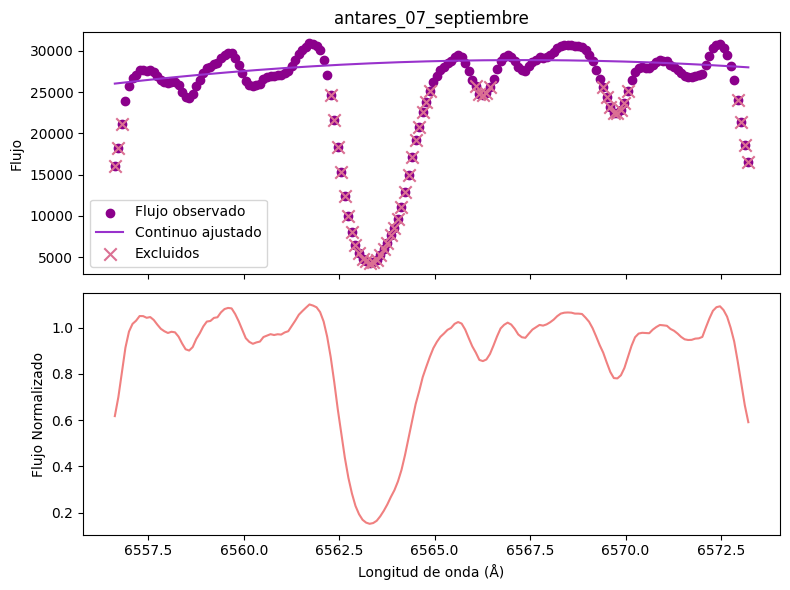


Proceso completo.


In [16]:
if guardar_graficos:
    Path(carpeta_graficos).mkdir(exist_ok=True)
 
for nombre, df in espectros_por_normalizar.items():
    print(f"\nProcesando: {nombre}")
 
    longitud_onda = df[col_longitud_onda].values
    flujo = df[col_flujo].values
 
    continuo, mascara_continuo = ajustar_continuo(longitud_onda, flujo, grado_polinomio, N_iteraciones, sigma_corte)

    df["Continuo ajustado"] = continuo
    df["Flujo Normalizado"] = flujo / continuo
    df["Usado en ajuste"] = mascara_continuo

    print(f"  Puntos totales: {len(mascara_continuo)}")
    print(f"  Puntos excluidos: {(~mascara_continuo).sum()}")

    mascara_bool = np.asarray(mascara_continuo, dtype=bool)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
 
    ax1.scatter(longitud_onda, flujo, color = "darkmagenta", label="Flujo observado")
    ax1.plot(longitud_onda, continuo, color ="darkorchid", label="Continuo ajustado")
    ax1.scatter(longitud_onda[~mascara_bool], flujo[~mascara_bool], color = "palevioletred",marker = "x", label="Excluidos", s = 80)
    ax1.set_ylabel("Flujo")
    ax1.legend()
    ax1.set_title(nombre)
 
    ax2.plot(longitud_onda, df["Flujo Normalizado"], color ="lightcoral")
    ax2.set_ylabel("Flujo Normalizado")
    ax2.set_xlabel("Longitud de onda (Å)")
 
    plt.tight_layout()
 
    if guardar_graficos:
        fig_path = Path(carpeta_graficos) / f"{nombre}_control.png"
        plt.savefig(fig_path, dpi=120)
        print(f"  -> Gráfico guardado: {fig_path}")
 
    plt.show()
    plt.close(fig)
 
print("\nProceso completo.")

<h3 style="color: #e19edc;"> Obtención del perfil de absorción y emisión de la línea H<sub>&alpha;</sub></h3>

<h4 style="color: #e19edc;"> Sin tener en cuenta las posibles mezclas de las líneas metálicas</h4>

In [ ]:
# #MODELO DE AJUSTE

# # Usamos Voigt para el valle ya que permite tener en cuenta las asimetrías del perfil de la línea de absorción

# def construccion_del_modelo():
#     continuo = ConstantModel(prefix="cont_")
#     em_azul = VoigtModel(prefix="em_azul_")
#     valle_abs = VoigtModel(prefix="valle_abs_")
#     return continuo + em_azul + valle_abs

# def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox):
#     p = modelo.make_params()

#     borde = np.r_[flujo[:10], flujo[-10:]]
#     p["cont_c"].set(value=np.median(borde), min=0, max=2)

#     izquierda = longitud_onda < centro_aprox

#     # Emisión azul
#     i_azul = np.argmax(flujo[izquierda])
#     p["em_azul_center"].set(value=longitud_onda[izquierda][i_azul],
#                              min=longitud_onda.min(), max=centro_aprox)
#     p["em_azul_amplitude"].set(value=1.0, min=0)
#     p["em_azul_sigma"].set(value=0.4, min=0.05, max=2)

#     # Absorción central
#     i_min = np.argmin(flujo)
#     p["valle_abs_center"].set(value=longitud_onda[i_min], min=centro_aprox - 1, max=centro_aprox + 1)
#     p["valle_abs_amplitude"].set(value=-(np.median(borde) - flujo[i_min]) * 1.5, max=0)
#     p["valle_abs_sigma"].set(value=0.3, min=0.03, max=1.2)
#     p["valle_abs_gamma"].set(value=0.2, min=0, max=1.2, vary=True)

#     return p


In [ ]:
# # DESCOMPOSICIÓN

# def fit_y_decomposición(datos_cercanos, centro_aprox, longitud_observada, flujo_normalizado):
#     longitud_onda = datos_cercanos[longitud_observada].to_numpy()
#     flujo = datos_cercanos[flujo_normalizado].to_numpy()

#     modelo = construccion_del_modelo()
#     parametros = encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox)
#     fit = modelo.fit(flujo, parametros, x=longitud_onda)

#     comps = fit.eval_components(x=longitud_onda)
#     continuo = comps["cont_"]

#     perfil_emision = continuo + comps["em_azul_"]  
#     perfil_absorcion = continuo + comps["valle_abs_"]
#     residuo = flujo - fit.best_fit

#     return dict(wave=longitud_onda, flux=flujo, fit=fit, comps=comps, perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion,
#                 residuo=residuo)

# def resumen_fisico(fit):
#     p = fit.params
#     print("\n--- Resumen del ajuste ---")
#     for comp, label in [("em_azul", "Emisión azul")]:
#         c = p[f"{comp}_center"].value
#         fwhm = p[f"{comp}_fwhm"].value
#         amp = p[f"{comp}_height"].value
#         print(f"{label:14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   altura={amp:5.3f}")

#     c = p["valle_abs_center"].value
#     fwhm = p["valle_abs_fwhm"].value
#     profundidad = p["valle_abs_height"].value
#     print(f"{'Absorción central':14s}: centro={c:9.3f} Å   FWHM={fwhm:5.2f} Å   profundidad={profundidad:5.3f}")

#     print(f"\nContinuo local ajustado: {p['cont_c'].value:.3f}")
#     print(f"Chi-cuadrado reducido:   {fit.redchi:.3e}")

In [ ]:
# # GRÁFICA

# def visualizacion_decomposicion(res, titulo="Descomposición H-alpha"):
#     longitud_observada, flujo, fit = res["wave"], res["flux"], res["fit"]
#     fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
#                               gridspec_kw={"height_ratios": [2.2, 1]})

#     ax = axes[0]
#     ax.scatter(longitud_observada, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
#     ax.plot(longitud_observada, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
#     ax.plot(longitud_observada, res["perfil_emision"], "--", color="turquoise", lw=1.5,
#             label="Perfil de emisión (sin absorción)")
#     ax.plot(longitud_observada, res["perfil_absorcion"], "--", color="deepskyblue", lw=1.5,
#             label="Perfil de absorción (sin emisión)")
#     ax.axhline(res["comps"]["cont_"][0], color="gray", lw=0.7, ls=":")
#     ax.set_ylabel("Flujo normalizado")
#     ax.set_title(titulo, fontsize=14, fontweight='bold')
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)

#     ax2 = axes[1]
#     ax2.plot(longitud_observada, res["residuo"], color="black", lw=1)
#     ax2.axhline(0, color="gray", lw=0.7)
#     ax2.set_xlabel("Longitud de onda [Å]")
#     ax2.set_ylabel("Residuo")
#     ax2.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.show()


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.135 Å   FWHM= 0.89 Å   altura=0.325
Absorción central: centro= 6563.304 Å   FWHM= 1.65 Å   profundidad=-0.720

Continuo local ajustado: 0.839
Chi-cuadrado reducido:   1.199e-03


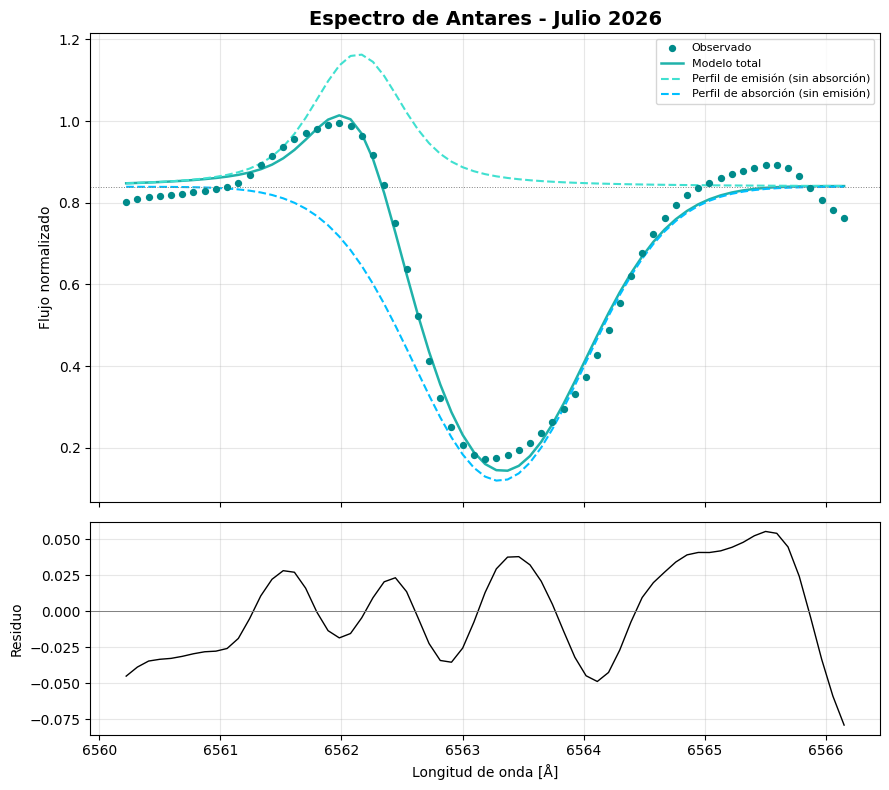

In [ ]:
# res = fit_y_decomposición(datos_cercanos_julio, centro_julio, "longitud_observada", "flujo_normalizado")
# resumen_fisico(res["fit"])
# visualizacion_decomposicion(res, titulo="Espectro de Antares - Julio 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.289 Å   FWHM= 0.89 Å   altura=0.383
Absorción central: centro= 6563.465 Å   FWHM= 1.70 Å   profundidad=-0.855

Continuo local ajustado: 0.962
Chi-cuadrado reducido:   2.294e-03


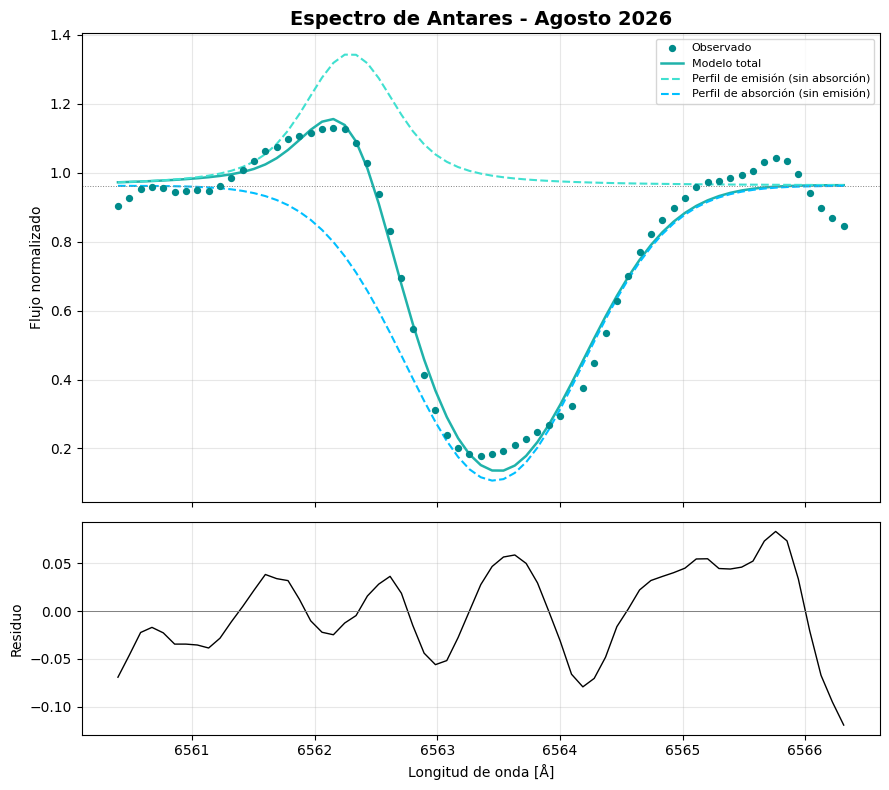

In [ ]:
# res_a = fit_y_decomposición(datos_cercanos_agosto, centro_agosto, "longitud_observada", "flujo_normalizado")
# resumen_fisico(res_a["fit"])
# visualizacion_decomposicion(res_a, titulo="Espectro de Antares - Agosto 2026")


--- Resumen del ajuste ---
Emisión azul  : centro= 6562.259 Å   FWHM= 0.92 Å   altura=0.297
Absorción central: centro= 6563.515 Å   FWHM= 1.68 Å   profundidad=-0.777

Continuo local ajustado: 0.895
Chi-cuadrado reducido:   1.629e-03


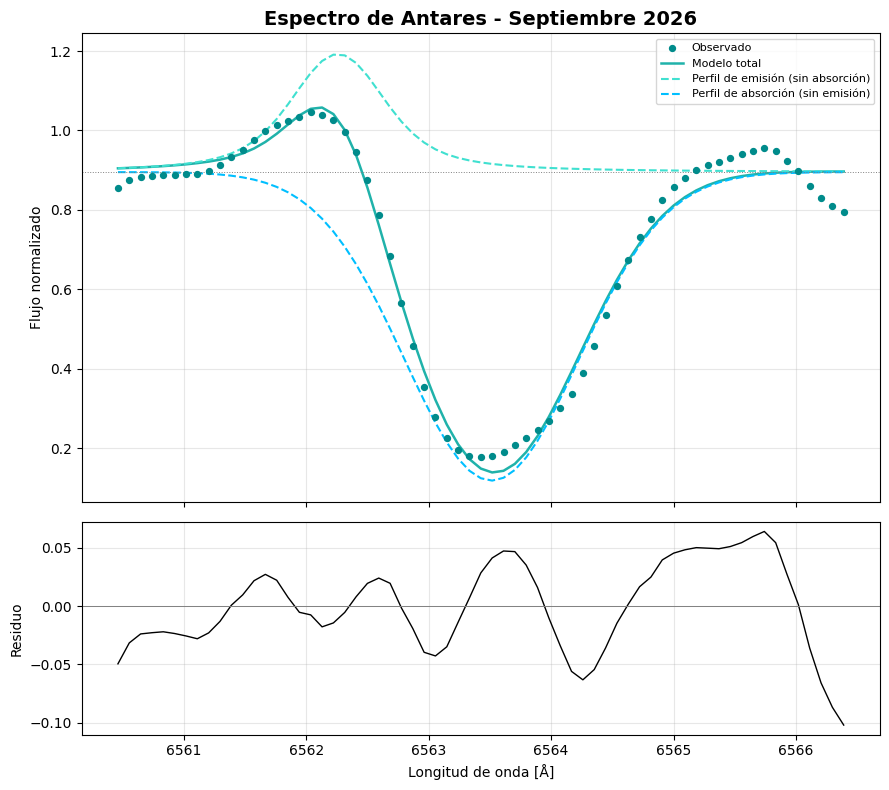

In [ ]:
# res_s = fit_y_decomposición(datos_cercanos_septiembre, centro_septiembre, "longitud_observada", "flujo_normalizado")
# resumen_fisico(res_s["fit"])
# visualizacion_decomposicion(res_s, titulo="Espectro de Antares - Septiembre 2026")

<h4 style="color: #e19edc;"> Teniendo en cuenta las posibles mezclas con las líneas de absorción</h4>


<h5 style="color: #e19edc;"> Datos </h5>

In [17]:
# Datos completos
archivos = [
    {
        "fecha": "Julio 11-2024",
        "datos": antares_11_julio,
        "ventana_vecinos":4,
        "centro_aprox": 6563.185,
        "velocidad_metalica": 19.4,  # km/s
        "incertidumbre_v": 0.36,
    },
    {
        "fecha": "Julio 22-2024",
        "datos": antares_22_julio,
        "ventana_vecinos":4,
        "centro_aprox": 6563.188,
        "velocidad_metalica": 22.19,  # km/s
        "incertidumbre_v": 0.33,
    },
    {
        "fecha": "Agosto 16-2024",
        "datos": antares_16_agosto,
        "ventana_vecinos":4,
        "centro_aprox": 6563.388,
        "velocidad_metalica": 27.17,  # km/s
        "incertidumbre_v": 0.3,
    },
    {
        "fecha": "Agosto 26-2024",
        "datos": antares_26_agosto,
        "ventana_vecinos":3,
        "centro_aprox": 6563.35,
        "velocidad_metalica": 28.38,  # km/s
        "incertidumbre_v": 0.31,
    },
    {
        "fecha": "Septiembre 06-2024",
        "datos": antares_06_septiembre,
        "ventana_vecinos":4,
        "centro_aprox": 6563.41,
        "velocidad_metalica": 28.47,  # km/s
        "incertidumbre_v": 0.29,
    },
    {
        "fecha": "Septiembre 19-2024",
        "datos": antares_19_septiembre,
        "ventana_vecinos":3,
        "centro_aprox": 6563.359,
        "velocidad_metalica": 27.43,  # km/s
        "incertidumbre_v": 0.3,
    },
    {
        "fecha": "Septiembre 24-2024",
        "datos": antares_24_septiembre,
        "ventana_vecinos":3,
        "centro_aprox": 6563.393,
        "velocidad_metalica": 26.82,  # km/s
        "incertidumbre_v": 0.32,
    },
    {
        "fecha": "Octubre 01-2024",
        "datos": antares_01_octubre,
        "ventana_vecinos":4,
        "centro_aprox": 6563.357,
        "velocidad_metalica": 26.42,  # km/s
        "incertidumbre_v": 0.29,
    },
    {
        "fecha": "Octubre 11-2024",
        "datos": antares_11_octubre,
        "ventana_vecinos":4,
        "centro_aprox": 6563.3,
        "velocidad_metalica": 22.32,  # km/s
        "incertidumbre_v": 0.32,
    },
    {
        "fecha": "Octubre 17-2024",
        "datos": antares_17_octubre,
        "ventana_vecinos":4,
        "centro_aprox": 6563.249,
        "velocidad_metalica": 19.88,  # km/s
        "incertidumbre_v": 0.37,
    },
    {
        "fecha": "Octubre 18-2024",
        "datos": antares_18_octubre,
        "ventana_vecinos":4,
        "centro_aprox": 6563.309,
        "velocidad_metalica": 19.46,  # km/s
        "incertidumbre_v": 0.34,
    },
    {
        "fecha": "Octubre 24-2024",
        "datos": antares_24_octubre,
        "ventana_vecinos":3,
        "centro_aprox": 6563.181,
        "velocidad_metalica": 17.58,  # km/s
        "incertidumbre_v": 0.29,
    },
    {
        "fecha": "Septiembre 06-2025",
        "datos": datos_cercanos_septiembre,
        "ventana_vecinos":3,
        "centro_aprox": centro_septiembre,
        "velocidad_metalica": 28.4,  # km/s
        "incertidumbre_v": 0.9,
    },
    {
        "fecha": "Julio 22-2026",
        "datos": datos_cercanos_julio,
        "ventana_vecinos":4,
        "centro_aprox": centro_julio,
        "velocidad_metalica": 22.1,   #km/s
        "incertidumbre_v": 0.9,
    },
    {
        "fecha": "Julio 24-2026",
        "datos": antares_24_julio,
        "ventana_vecinos":4,
        "centro_aprox": 6563.175,
        "velocidad_metalica": 17.67,   #km/s
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Julio 27-2026",
        "datos": antares_27_julio,
        "ventana_vecinos":4,
        "centro_aprox": 6563.119,
        "velocidad_metalica": 17.77,   #km/s
        "incertidumbre_v": 0.42,
    },
    {
        "fecha": "Agosto 06-2026",
        "datos": antares_06_agosto,
        "ventana_vecinos":3,
        "centro_aprox": 6563.268,
        "velocidad_metalica": 20.23,   #km/s
        "incertidumbre_v": 0.41,
    },
    {
        "fecha": "Agosto 10-2026",
        "datos": antares_10_agosto,
        "ventana_vecinos":3,
        "centro_aprox": 6563.282,
        "velocidad_metalica": 21.37,   #km/s
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Agosto 13-2026",
        "datos": antares_13_agosto,
        "ventana_vecinos":3,
        "centro_aprox": 6563.214,
        "velocidad_metalica": 21.16,   #km/s
        "incertidumbre_v": 0.43,
    },
    {
        "fecha": "Agosto 26-2026",
        "datos": datos_cercanos_agosto,
        "ventana_vecinos":3,
        "centro_aprox": centro_agosto,
        "velocidad_metalica": 28.3,  # km/s 
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Agosto 28-2026",
        "datos": antares_28_agosto,
        "ventana_vecinos":3,
        "centro_aprox": 6563.282,
        "velocidad_metalica": 24.76,   #km/s
        "incertidumbre_v": 0.39,
    },
    {
        "fecha": "Septiembre 07-2026",
        "datos": antares_07_septiembre,
        "ventana_vecinos":3,
        "centro_aprox": 6563.39,
        "velocidad_metalica": 23.68,   #km/s
        "incertidumbre_v": 0.39,
    }
    
]


<h5 style="color: #e19edc;"> Funciones Auxiliares</h5>

In [18]:
c_kms_s = 299792.458

def efecto_doppler(longitud_lab, velocidad_kms):
    return longitud_lab * (1 + velocidad_kms / c_kms_s)


def profundidad_interpolada(teff, t_ref=(3500, 4250), prof_ref=(0.55, 0.63)):
    return float(np.interp(teff, t_ref, prof_ref))


def pico_unitario_voigt(sigma, gamma):
    z = 1j * gamma / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))

In [19]:
def estimar_continuo_por_planitud(longitud_onda, flujo, rango_flujo,max_variacion=0.015, ventana_vecinos=2,
                                    grado_ajuste=1, min_puntos=5):

    serie_flujo = pd.Series(flujo)

    ventana_total = 2 * ventana_vecinos + 1
    variacion_local = serie_flujo.rolling(window=ventana_total, center=True).std()

    mascara_rango = (flujo >= rango_flujo[0]) & (flujo <= rango_flujo[1])
    mascara_plano = (variacion_local < max_variacion).to_numpy()

    mascara = mascara_rango & mascara_plano

    x_sel = longitud_onda[mascara]
    y_sel = flujo[mascara]

    if x_sel.size < min_puntos:
        raise ValueError(
            f"Solo se encontraron {x_sel.size} puntos de continuo (mínimo {min_puntos}). "
            f"Ajustá 'rango_flujo' o 'max_variacion'. Rango de flujo real en este espectro: "
            f"[{flujo.min():.3f}, {flujo.max():.3f}]"
        )

    orden = np.argsort(x_sel)
    x_sel, y_sel = x_sel[orden], y_sel[orden]

    coef = np.polyfit(x_sel, y_sel, deg=grado_ajuste)
    continuo_func = np.poly1d(coef)

    return continuo_func, x_sel, y_sel


<h5 style="color: #e19edc;"> Prueba específica por espectro para el continuo con grado 1</h5>

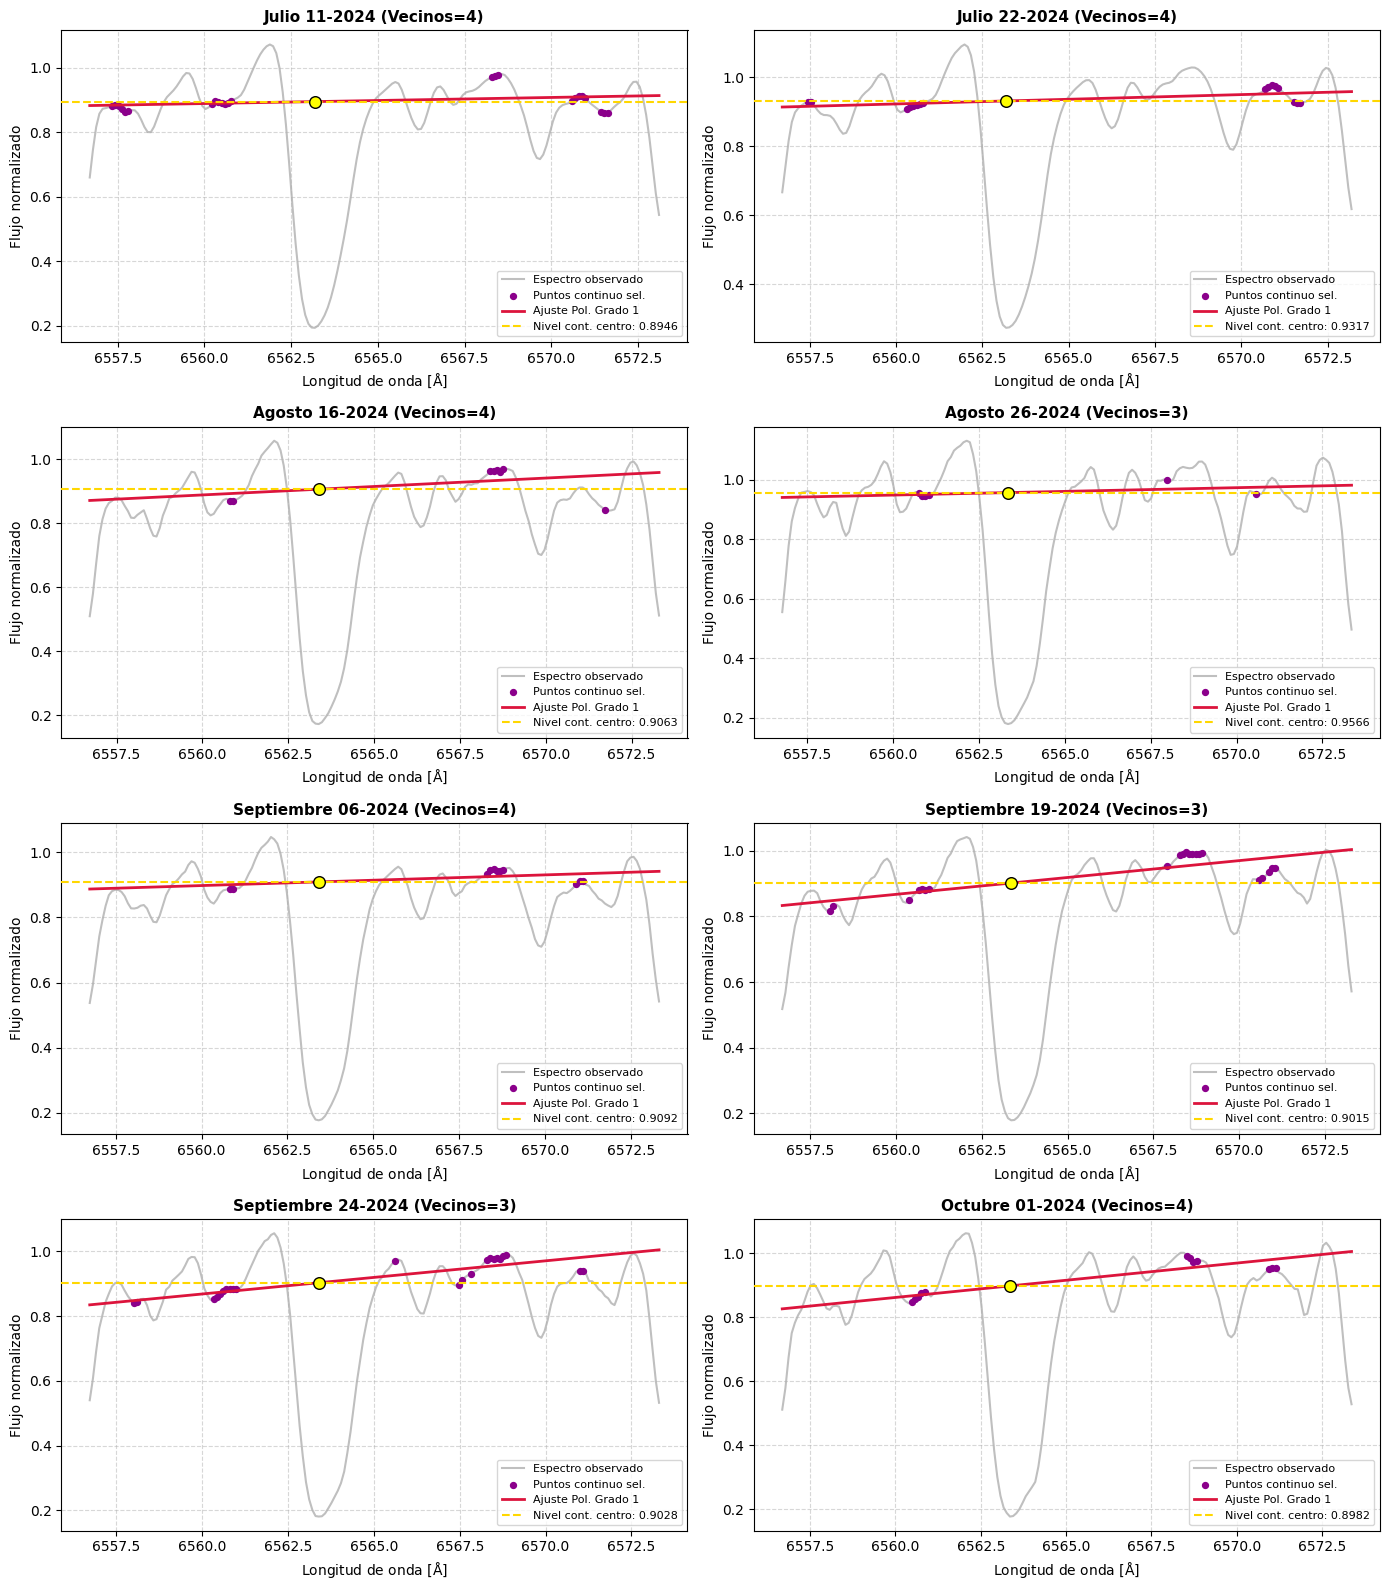

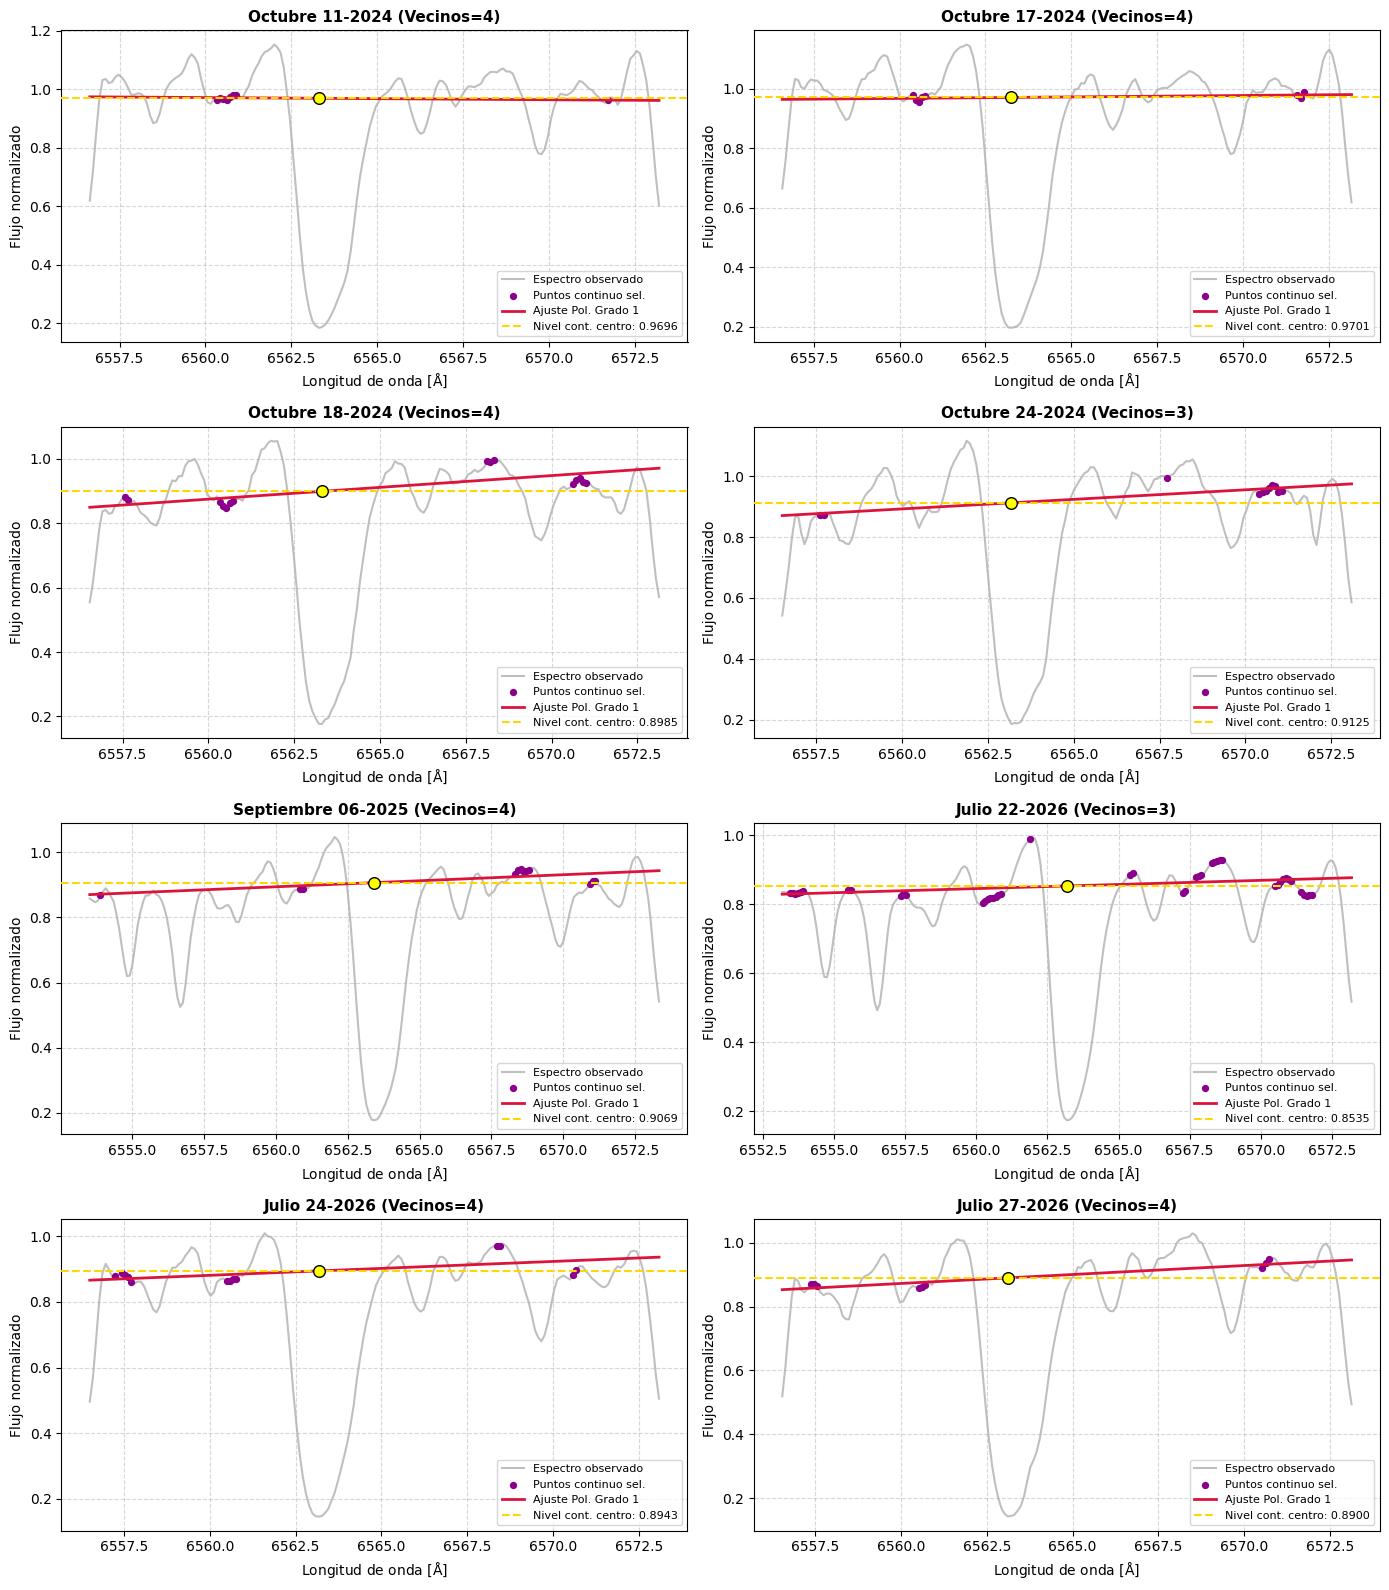

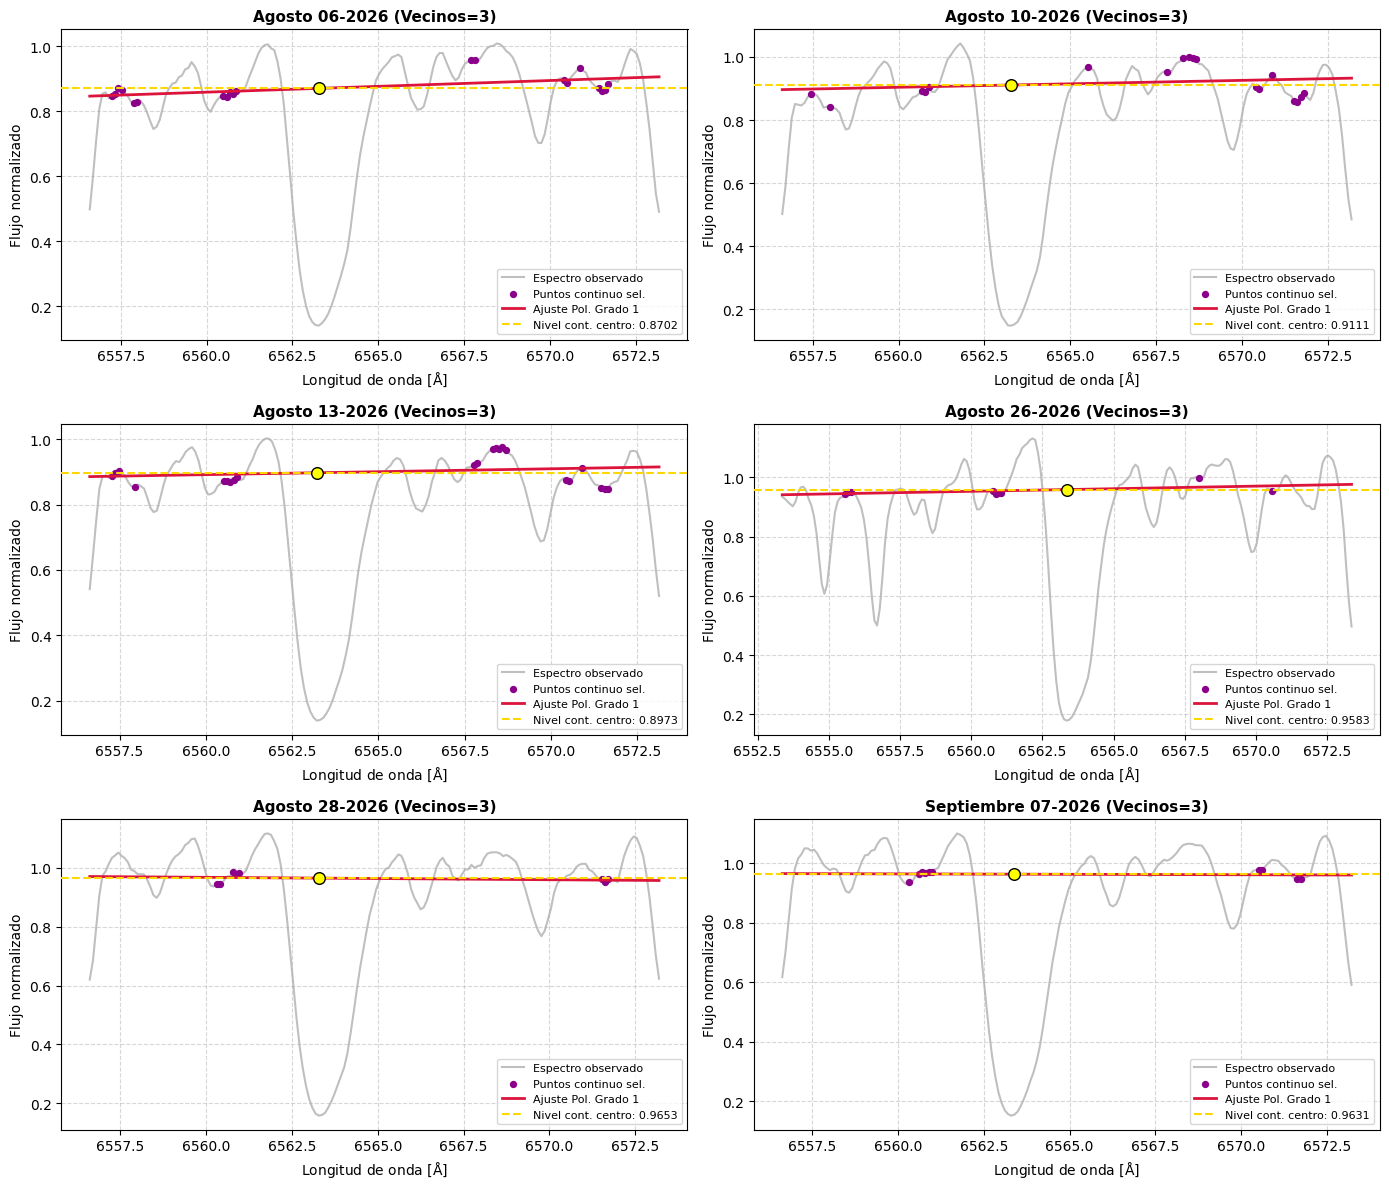

,Espectro / Fecha,Vecinos (G1),Continuo Centro (G1),Residuo std (G1)
0,Julio 11-2024,4,0.8946,0.03095
1,Julio 22-2024,4,0.9317,0.01783
2,Agosto 16-2024,4,0.9063,0.04659
3,Agosto 26-2024,3,0.9566,0.01532
4,Septiembre 06-2024,4,0.9092,0.01951
5,Septiembre 19-2024,3,0.9015,0.03338
6,Septiembre 24-2024,3,0.9028,0.02507
7,Octubre 01-2024,4,0.8982,0.02233
8,Octubre 11-2024,4,0.9696,0.00603
9,Octubre 17-2024,4,0.9701,0.00780


In [22]:
# Configuración manual de vecinos por prueba específica
vecinos_manuales = {
    "Julio 11-2024": {"v_g1": 4},
    "Julio 22-2024": {"v_g1": 4},
    "Agosto 16-2024": {"v_g1": 4},
    "Agosto 26-2024": {"v_g1": 3},
    "Septiembre 06-2024": {"v_g1": 4},
    "Septiembre 19-2024": {"v_g1": 3},
    "Septiembre 24-2024": {"v_g1": 3},
    "Octubre 01-2024": {"v_g1": 4},
    "Octubre 11-2024": {"v_g1": 4},
    "Octubre 17-2024": {"v_g1": 4},
    "Octubre 18-2024": {"v_g1": 4},
    "Octubre 24-2024": {"v_g1": 3},
    "Septiembre 06-2025": {"v_g1": 4},
    "Julio 22-2026": {"v_g1": 3},
    "Julio 24-2026": {"v_g1": 4},
    "Julio 27-2026": {"v_g1": 4},
    "Agosto 06-2026": {"v_g1": 3},
    "Agosto 10-2026": {"v_g1": 3},
    "Agosto 13-2026": {"v_g1": 3},
    "Agosto 26-2026": {"v_g1": 3},
    "Agosto 28-2026": {"v_g1": 3},
    "Septiembre 07-2026": {"v_g1": 3},
}

filas_comparativa = []

n_columnas = 2
max_filas = 4
tam_bloque = n_columnas * max_filas

n_bloques = int(np.ceil(len(archivos) / tam_bloque))

for bloque_idx in range(n_bloques):

    bloque = archivos[bloque_idx * tam_bloque: (bloque_idx + 1) * tam_bloque]
    n_graficas = len(bloque)
    n_filas_bloque = int(np.ceil(n_graficas / n_columnas))

    fig, axes = plt.subplots(
        n_filas_bloque,
        n_columnas,
        figsize=(14, 4 * n_filas_bloque)
    )

    axes = np.array(axes).flatten()

    for i, archivo in enumerate(bloque):

        fecha = archivo["fecha"]
        df = archivo["datos"]
        centro_aprox = archivo["centro_aprox"]

        longitud_onda = df["Longitud onda"].values
        flujo = df["Flujo Normalizado"].values

        # Extraer ventana manual

        cfg = vecinos_manuales.get(fecha, {"v_g1": 2})
        v_g1 = cfg["v_g1"]

        # Grado 1

        try:

            cont_func1, x_sel1, y_sel1 = estimar_continuo_por_planitud(longitud_onda, flujo,
                rango_flujo=(0.8, 1), max_variacion=0.015, ventana_vecinos=v_g1, grado_ajuste=1)

            res1 = y_sel1 - cont_func1(x_sel1)

            c_centro1 = round(float(cont_func1(centro_aprox)), 4)

            std1 = round(float(np.std(res1)), 5)

        except Exception as e:

            cont_func1 = None
            c_centro1, std1 = None, f"Falló: {e}"

        # Tabla de resultados

        filas_comparativa.append({
            "Espectro / Fecha": fecha,
            "Vecinos (G1)": v_g1,
            "Continuo Centro (G1)": c_centro1,
            "Residuo std (G1)": std1
        })

        # Selección de Subplot con base en el índice

        ax = axes[i]

        ax.plot(longitud_onda, flujo, color="gray", alpha=0.5, label="Espectro observado", zorder=1)

        if cont_func1 is not None:

            # Continuo
            ax.scatter(x_sel1, y_sel1, color="darkmagenta", s=18, label="Puntos continuo sel.", zorder=2)

            # Ajuste polinómico
            ax.plot(longitud_onda, cont_func1(longitud_onda), color="crimson", lw=2, label="Ajuste Pol. Grado 1",
                     zorder=3)

            # Continuo evaluado en Hα
            ax.axhline(c_centro1, color="gold", linestyle="--", lw=1.5,
                       label=f"Nivel cont. centro: {c_centro1:.4f}", zorder=3)

            # Punto del centro aproximado
            ax.scatter([centro_aprox], [c_centro1], color="yellow", edgecolor="black", s=70, zorder=4)

        # Configuración del subplot
        ax.set_title(f"{fecha} (Vecinos={v_g1})", fontsize=11, fontweight="bold")
        ax.set_xlabel(r"Longitud de onda [$\mathrm{\AA}$]")
        ax.set_ylabel("Flujo normalizado")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, linestyle="--", alpha=0.5)

    # Eliminación de subplots vacíos si el número de espectros del bloque es impar

    for j in range(n_graficas, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    sufijo = f"_parte{bloque_idx + 1}" if n_bloques > 1 else ""

    plt.savefig(fr"Graficas 2024, 2025 y 2026\Continuo\Continuo_espectros_normalizados_ESPARTACO2{sufijo}.png",
        dpi=300, bbox_inches="tight")

    plt.show()

tabla_comparativa_manual = pd.DataFrame(filas_comparativa)

display(tabla_comparativa_manual)

In [23]:
def estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, centro_obs, ventana=0.5, sigma_default=0.12, gamma_default=0.05):

    mask = np.abs(longitud_onda - centro_obs) < ventana
    if mask.sum() < 4:
        return sigma_default, gamma_default

    x_local = longitud_onda[mask]
    y_local = flujo[mask]


    nivel_min = np.percentile(y_local, 2)
    prof_local = continuo_local - nivel_min
    if prof_local <= 0:
        return sigma_default, gamma_default

    nivel_media_altura = continuo_local - prof_local / 2

    por_debajo = y_local < nivel_media_altura
    if por_debajo.sum() < 2:
        return sigma_default, gamma_default

    x_cruce = x_local[por_debajo]
    fwhm_est = x_cruce.max() - x_cruce.min()

    if fwhm_est <= 0:
        return sigma_default, gamma_default

    sigma_inicial = max(0.02, fwhm_est / 2.355)
    gamma_inicial = max(0.0, fwhm_est * 0.15)

    return sigma_inicial, gamma_inicial


<h5 style="color: #e19edc;"> Construcción del Modelo </h5>

In [24]:
#MODELO DE AJUSTE

def construccion_del_modelo(lineas_metalicas=None):
    continuo = ConstantModel(prefix="cont_")
    em_azul = VoigtModel(prefix="em_azul_")
    valle_abs = VoigtModel(prefix="valle_abs_")
    modelo = continuo + em_azul + valle_abs

    if lineas_metalicas:
        for linea in lineas_metalicas:
            modelo += VoigtModel(prefix=f"{linea['nombre']}_")

    return modelo

In [25]:
def encontrar_parametros(modelo, longitud_onda, flujo, centro_aprox, continuo_func=None, x_sel=None, y_sel=None,
                         lineas_metalicas=None, teff=3660,rango_flujo=(0.8, 1.0), max_variacion=0.015, ventana_vecinos=2):
    
    p = modelo.make_params()
    p._asteval.symtable['pico_unitario_voigt'] = pico_unitario_voigt

    # Continuo (Planitud)
    if continuo_func is None or x_sel is None or y_sel is None:
        continuo_func, x_sel, y_sel = estimar_continuo_por_planitud(
            longitud_onda, flujo, rango_flujo=rango_flujo, 
            max_variacion=max_variacion, ventana_vecinos=ventana_vecinos, grado_ajuste=1
        )

    # Continuo en el centro de la línea (aproximado)
    continuo_local = float(continuo_func(centro_aprox))
    
    # Dispersión (ruido) respecto al ajuste polinomial
    residuos_continuo = y_sel - continuo_func(x_sel)
    disp_continuo = float(np.std(residuos_continuo))

    # Definición de márgenes y parámetro en lmfit
    margen = max(0.05, 4 * disp_continuo)
    p["cont_c"].set(value=continuo_local, min=continuo_local - margen, max=continuo_local + margen)


    # Emisión Azul
    flujo_suave = median_filter(flujo, size=5)
    izquierda = (longitud_onda < (centro_aprox - 0.2)) & (longitud_onda > (centro_aprox - 2.5))

    if np.any(izquierda):
        x_izq = longitud_onda[izquierda]
        y_izq = flujo_suave[izquierda]
        picos, props = find_peaks(y_izq, prominence=0.01)

        if len(picos) > 0:
            idx_mejor = picos[np.argmax(props["prominences"])]
            c_azul_inicio = x_izq[idx_mejor]
            amp_azul_inicio = max(0.05, flujo[izquierda][idx_mejor] - continuo_local)
        else:
            i_azul = np.argmax(y_izq)
            c_azul_inicio = x_izq[i_azul]
            amp_azul_inicio = max(0.05, flujo[izquierda][i_azul] - continuo_local)
    else:
        c_azul_inicio = centro_aprox - 0.8
        amp_azul_inicio = 0.2

    p["em_azul_center"].set(value=c_azul_inicio, min=centro_aprox - 2.8, max=centro_aprox - 0.15)
    p["em_azul_amplitude"].set(value=amp_azul_inicio * 0.5, min=0, max=amp_azul_inicio * 5.0)
    p["em_azul_sigma"].set(value=0.30, min=0.05, max=1.2)
    p["em_azul_gamma"].set(value=0.15, min=0.0, max=1.0, vary=True)

    # Absorción Central
    
    ventana_centro = np.abs(longitud_onda - centro_aprox) < 1.8
    if np.any(ventana_centro):
        idx_local = np.argmin(flujo_suave[ventana_centro])
        c_abs_inicio = longitud_onda[ventana_centro][idx_local]
    else:
        c_abs_inicio = centro_aprox

    i_min = np.argmin(np.abs(longitud_onda - c_abs_inicio))

    p["valle_abs_center"].set(value=c_abs_inicio, min=centro_aprox - 1.0, max=centro_aprox + 1.0)

    prof_abs_est = max(0.1, continuo_local - flujo[i_min])
    amp_abs_inicio = -prof_abs_est * 0.8
    p["valle_abs_amplitude"].set(value=amp_abs_inicio, min=-5.0, max=0)
    p["valle_abs_sigma"].set(value=0.25, min=0.05, max=1.0)
    p["valle_abs_gamma"].set(value=0.15, min=0, max=0.8, vary=True)

    # Líneas Metálicas
    
    if lineas_metalicas:
        for linea in lineas_metalicas:
            pref = f"{linea['nombre']}_"
            c0_lab = linea["centro"]

            v = linea.get("velocidad", 0.0)
            c0_obs = efecto_doppler(c0_lab, v)
            margen_v = linea.get("incertidumbre_v", 3.0)
            margen_aa = c0_lab * margen_v / c_kms_s
            p[f"{pref}center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

            # Estimación del ancho inicial
            sigma0_dato, gamma0_dato = estimar_ancho_inicial_metalica(longitud_onda, flujo, continuo_local, c0_obs)

            sigma0 = linea.get("sigma_inicial", sigma0_dato)
            gamma0 = linea.get("gamma_inicial", gamma0_dato)

            sigma_margen = 0.05
            gamma_margen = 0.05
            p[f"{pref}sigma"].set(value=sigma0, min=max(0.02, sigma0 - sigma_margen), max=min(0.4, sigma0 + sigma_margen))
            p[f"{pref}gamma"].set(value=gamma0, min=max(0.0, gamma0 - gamma_margen), max=min(0.3, gamma0 + gamma_margen), vary=True)

            prof = linea.get("profundidad")
            if prof is None:
                prof = profundidad_interpolada(teff, t_ref=linea.get("t_ref", (3500, 4250)), prof_ref=linea.get("prof_ref", (0.55, 0.63)))

            p[f"{pref}amplitude"].set(expr=f"-{prof} * cont_c / pico_unitario_voigt({pref}sigma, {pref}gamma)")

    return p, continuo_func

In [26]:
# DESCOMPOSICIÓN DE "PERFILES"

def fit_y_decomposicion(datos_cercanos, centro_aprox, col_longitud="Longitud onda", 
                        col_flujo="Flujo Normalizado", continuo_func=None, 
                        x_sel=None, y_sel=None, lineas_metalicas=None, teff=3660, ventana_vecinos = 2):
    
    # Extraemos los datos numéricos de la ventana recortada
    longitud_onda = datos_cercanos[col_longitud].to_numpy()
    flujo = datos_cercanos[col_flujo].to_numpy()

    # Construimos el modelo con lmfit
    modelo = construccion_del_modelo(lineas_metalicas)
    
    # Contiuo local
    parametros, cont_func_usado = encontrar_parametros(
        modelo, longitud_onda, flujo, centro_aprox,
        continuo_func=continuo_func, x_sel=x_sel, y_sel=y_sel,
        lineas_metalicas=lineas_metalicas, teff=teff, ventana_vecinos = ventana_vecinos)
    
    # Ajuste
    fit = modelo.fit(flujo, parametros, x=longitud_onda, nan_policy='omit')

    # Evaluación de componentes
    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_emision = continuo + comps.get("em_azul_", 0)
    perfil_absorcion = continuo + comps.get("valle_abs_", 0)
    residuo = flujo - fit.best_fit

    return dict(
        longitud_onda=longitud_onda, flujo=flujo, fit=fit, comps=comps, 
        perfil_emision=perfil_emision, perfil_absorcion=perfil_absorcion, 
        residuo=residuo, continuo_func=cont_func_usado)

<h5 style="color: #e19edc;"> Gráficas Individuales</sub></h5>

In [ ]:
# # VISUALIZACIÓN

# def visualizacion_con_metalica(res_metal, lineas_metalicas, mes, titulo, rango_x = None):
#     longitud_onda, flujo, fit = res_metal["longitud_onda"], res_metal["flujo"], res_metal["fit"]
#     comps = res_metal["comps"]
#     continuo = comps["cont_"]

#     fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
#                               gridspec_kw={"height_ratios": [2.2, 1]})

#     ax = axes[0]
#     ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
#     ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
#     ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3,
#             label="Perfil de emisión")
#     ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
#             label=r"Perfil de absorción $H_\alpha$")

#     for linea in lineas_metalicas:
#         pref = f"{linea['nombre']}_"
#         perfil_metal = continuo + comps[pref]
#         ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=1.3,
#                 label=f"Componente {linea['nombre']}")
#         ax.axvline(fit.params[f"{pref}center"].value, color="orchid", lw=2.5, ls=":", alpha=0.7)

#     ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
#     ax.set_ylabel("Flujo normalizado")
#     ax.set_title(titulo, fontsize=14, fontweight='bold')
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)

#     ax2 = axes[1]
#     ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
#     ax2.axhline(0, color="gray", lw=0.7)
#     ax2.set_xlabel("Longitud de onda [Å]")
#     ax2.set_ylabel("Residuo")
#     ax2.grid(alpha=0.3)

#     if rango_x is not None:
#         ax.set_xlim(rango_x)

#     plt.tight_layout()
#     plt.savefig(fr"Modelamiento\Graficas 2024, 2025 y 2026\halpha_{mes.lower()}_cobalto.png", dpi=150)
#     plt.show()

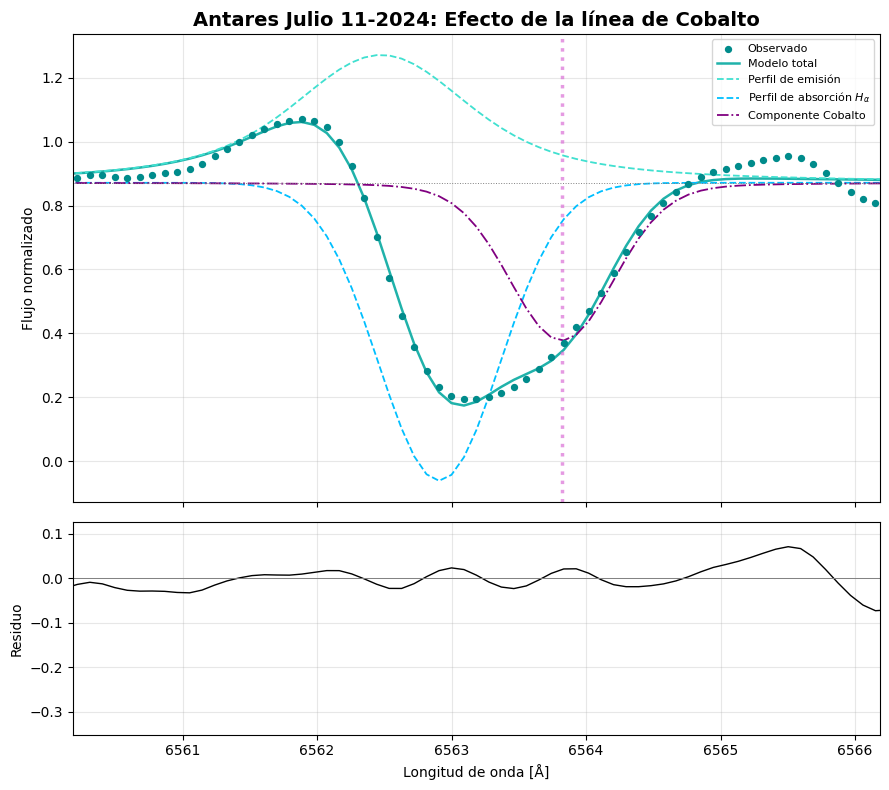

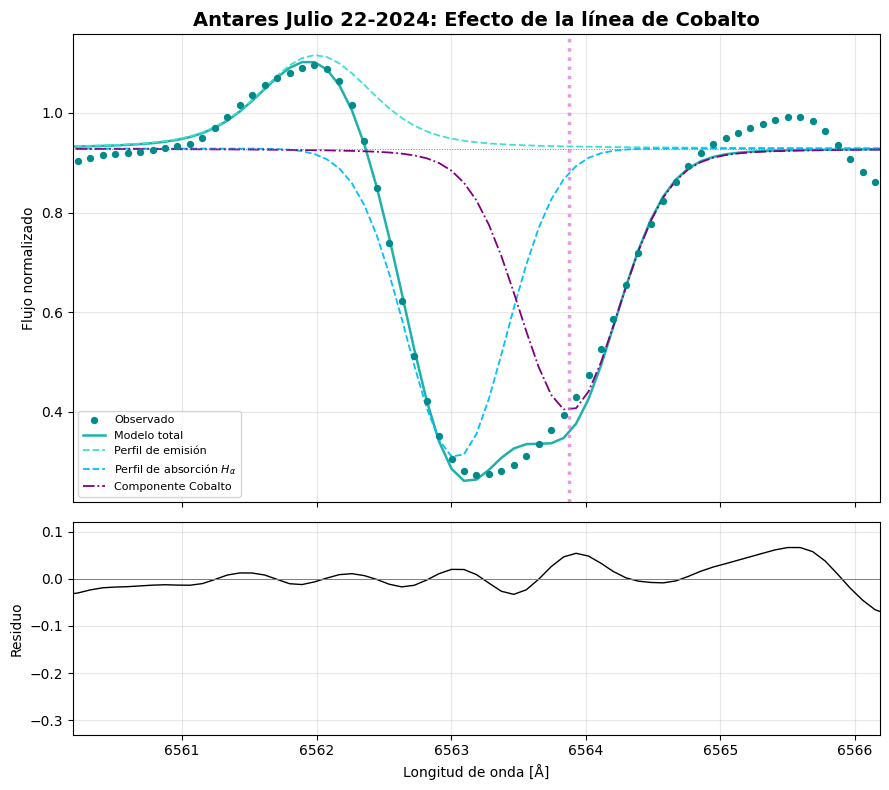

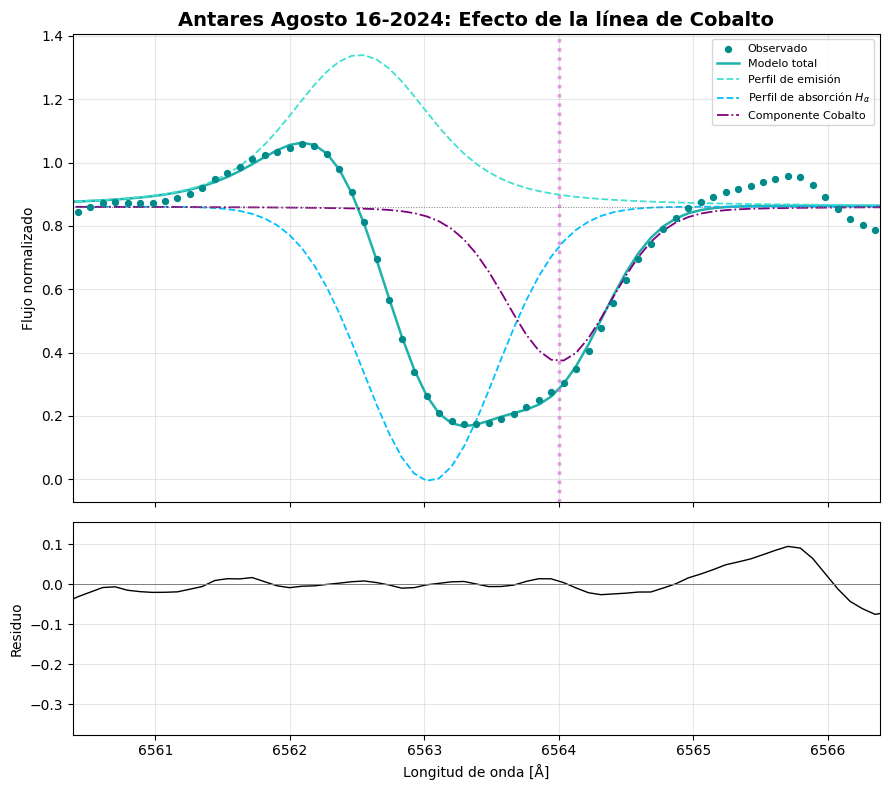

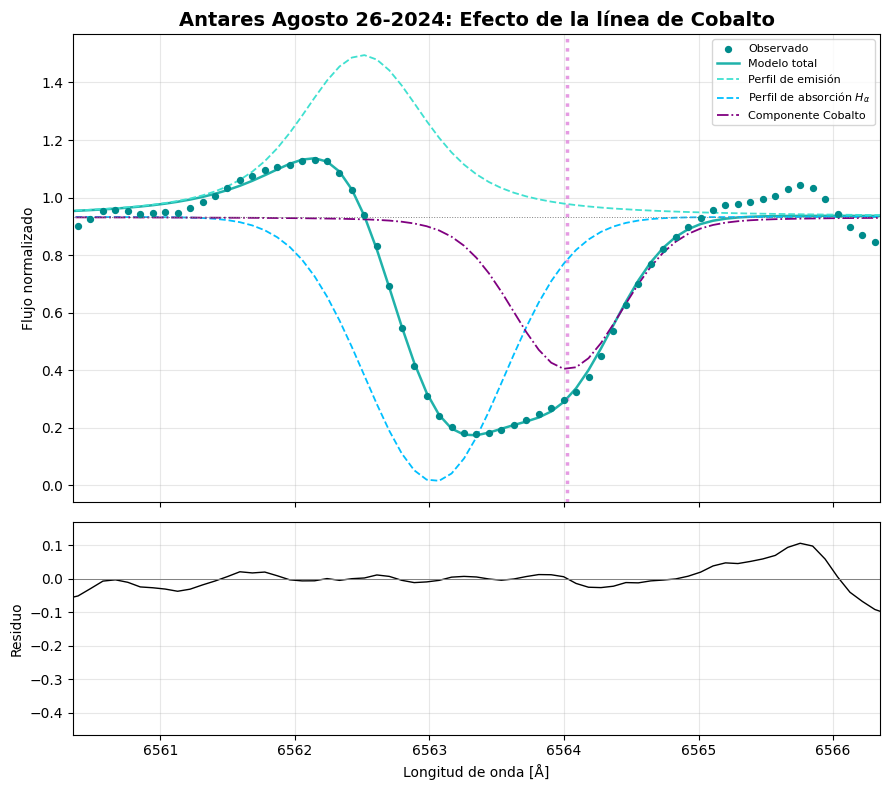

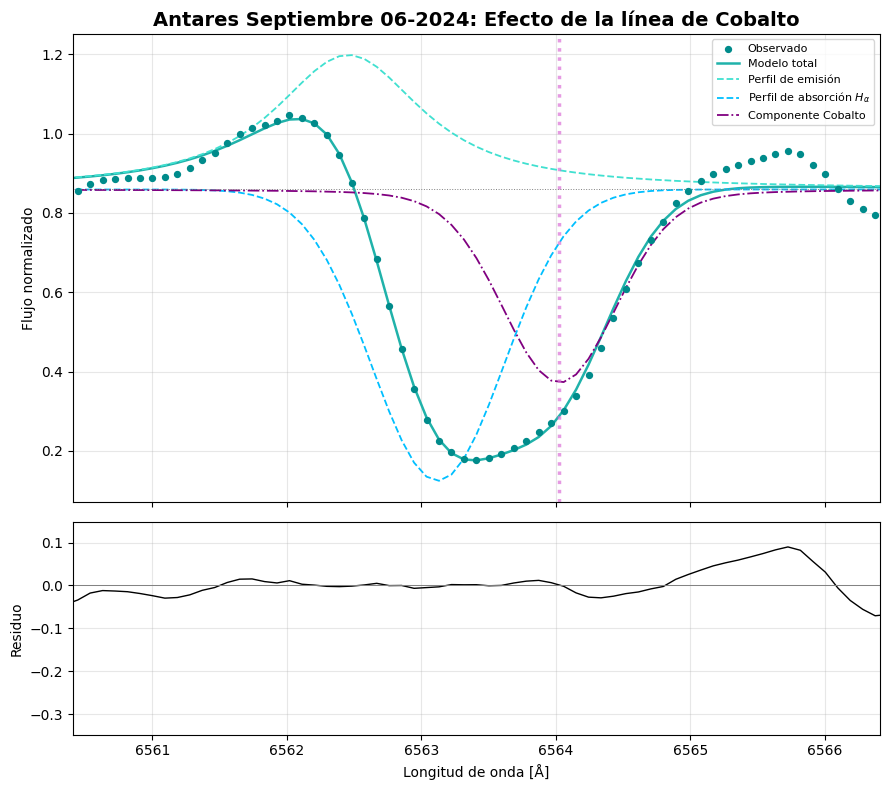

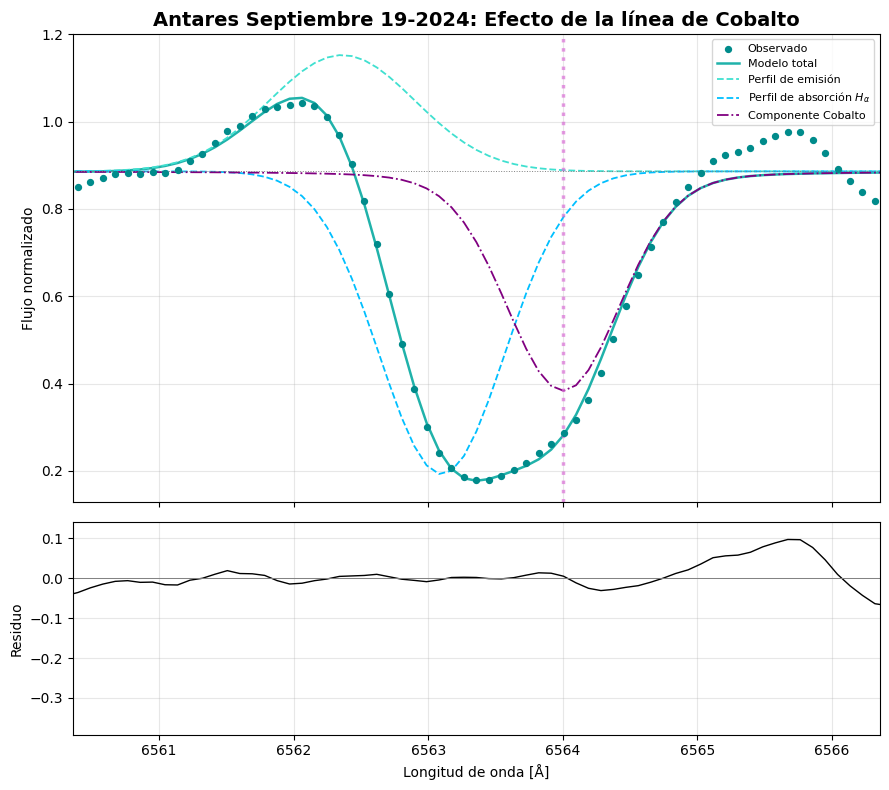

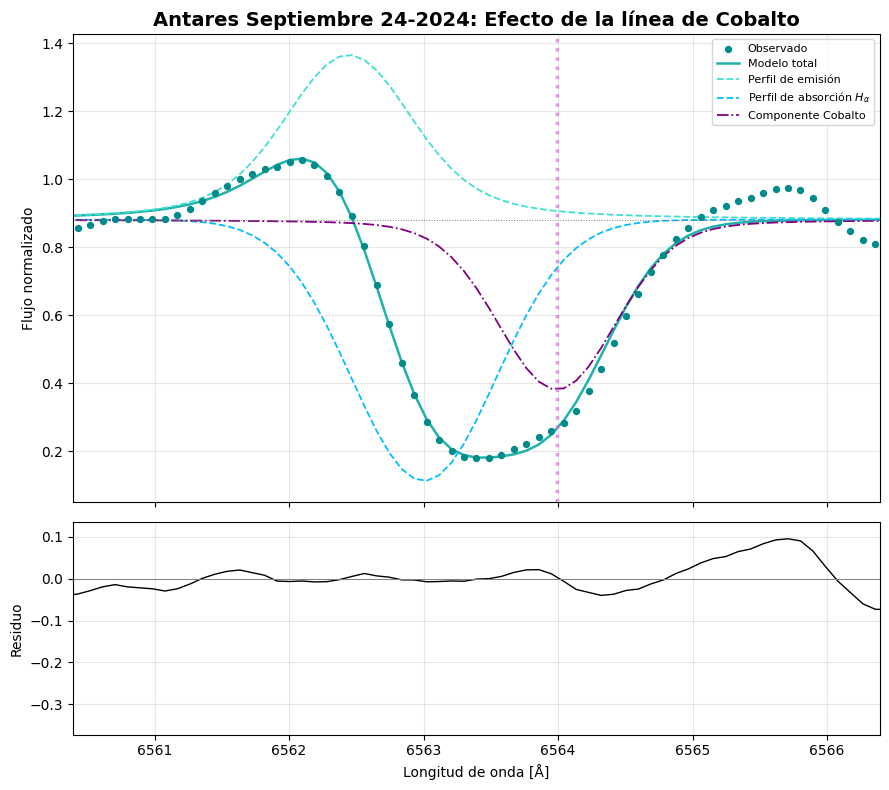

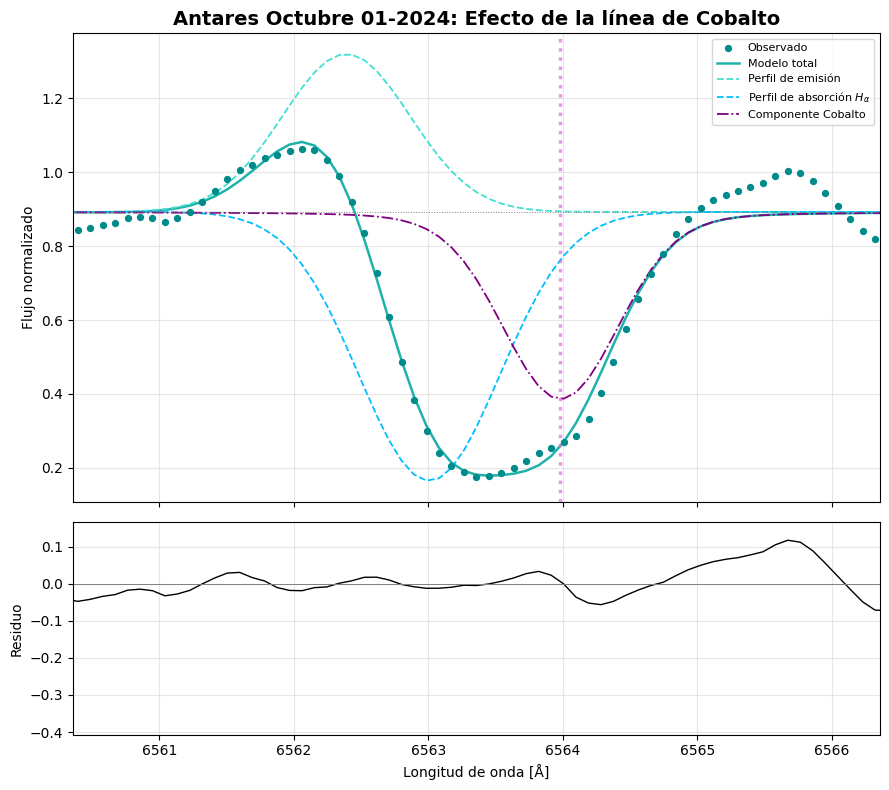

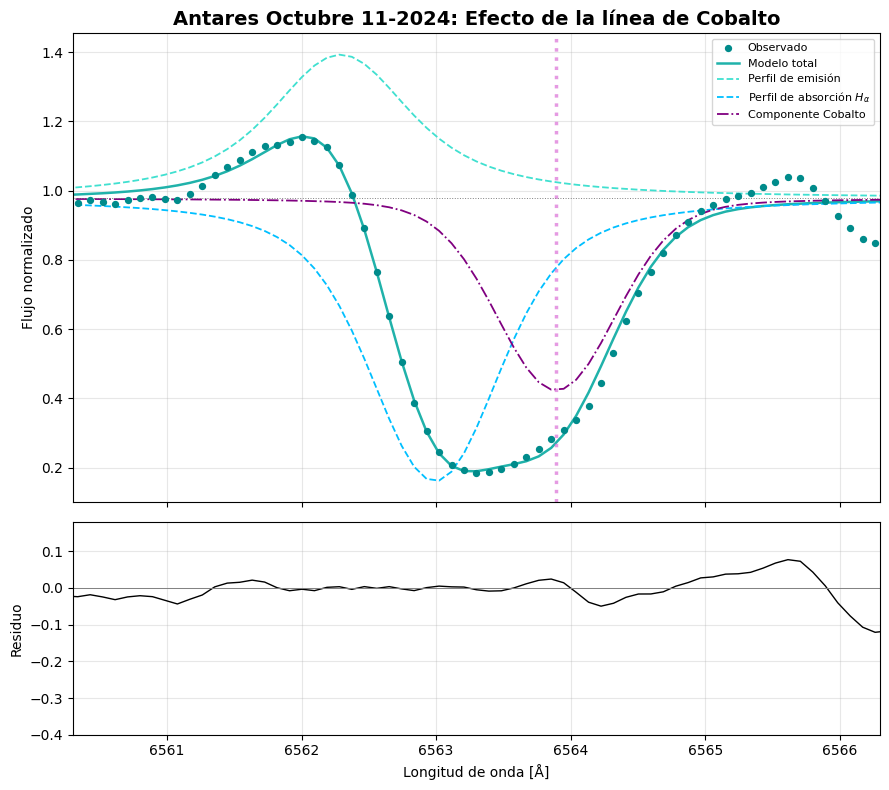

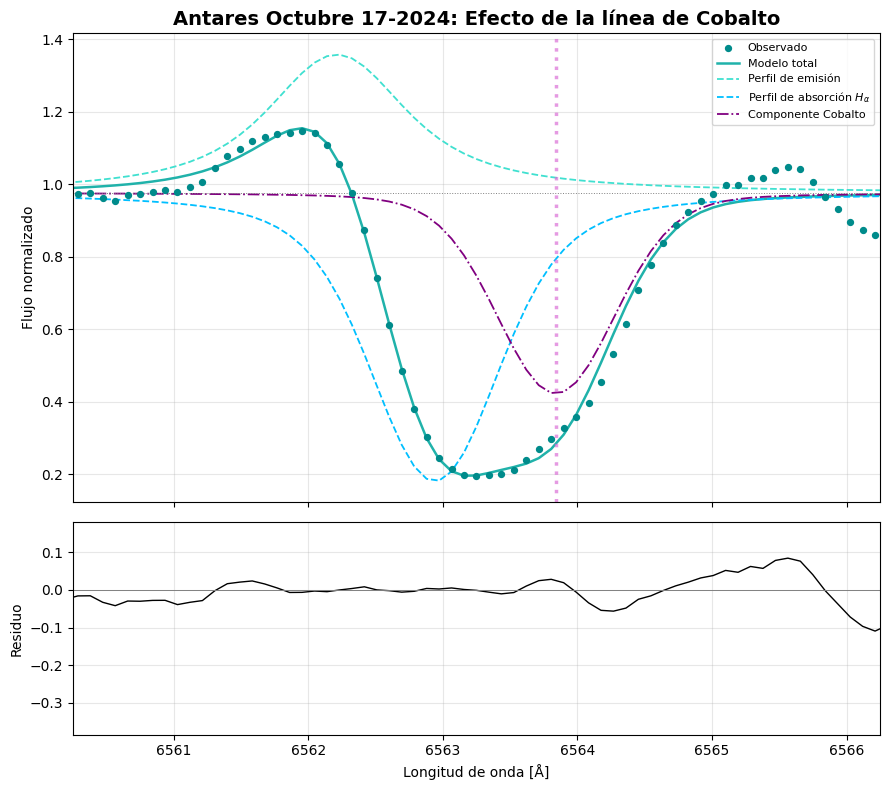

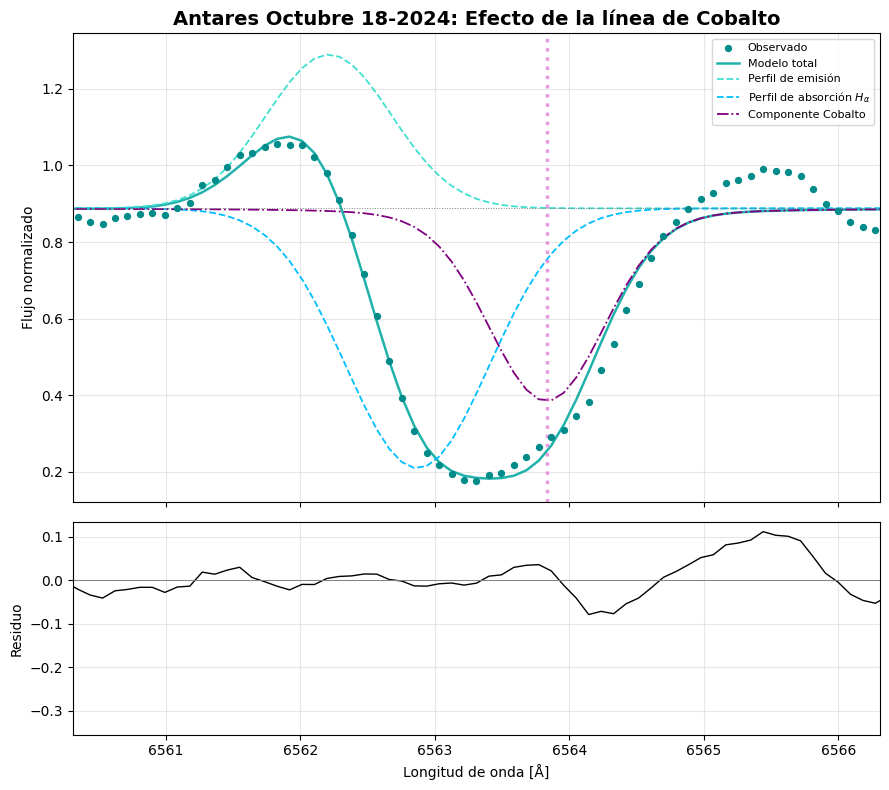

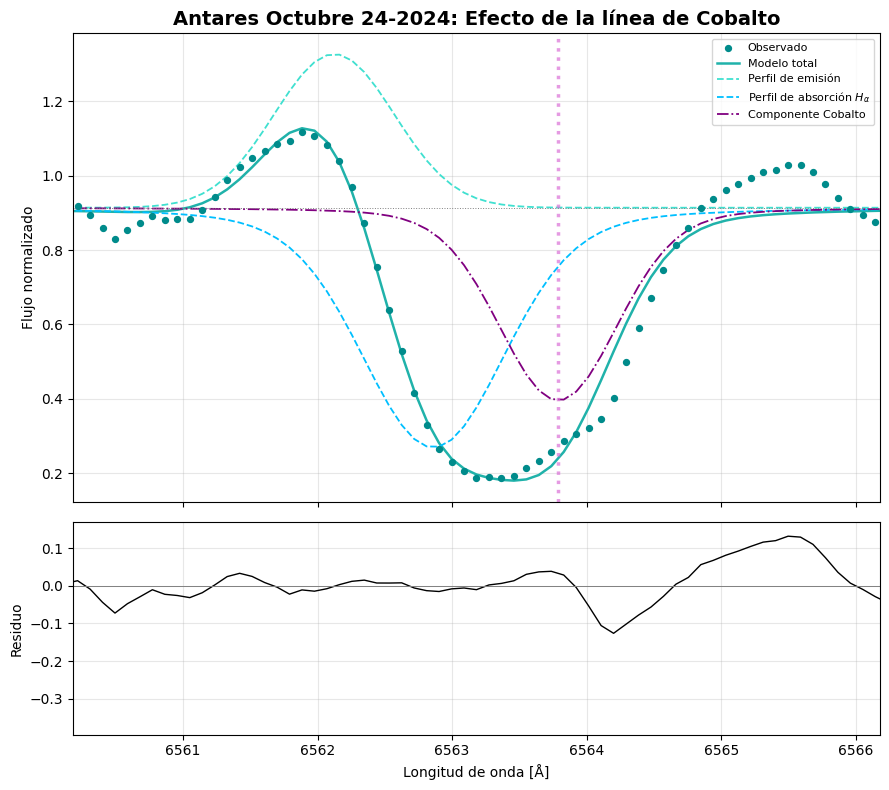

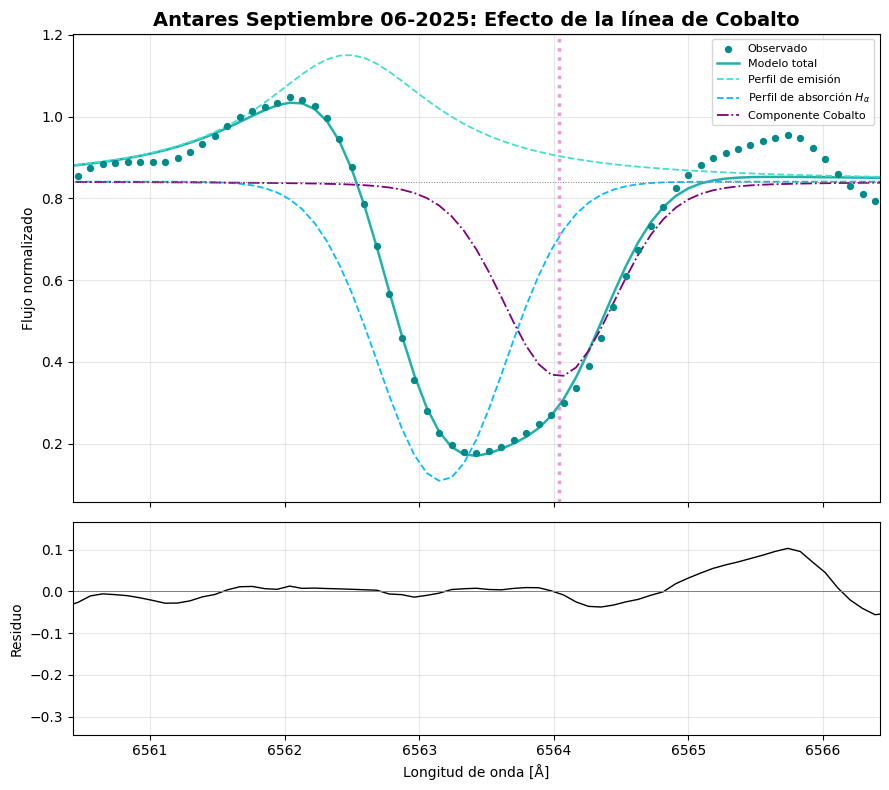

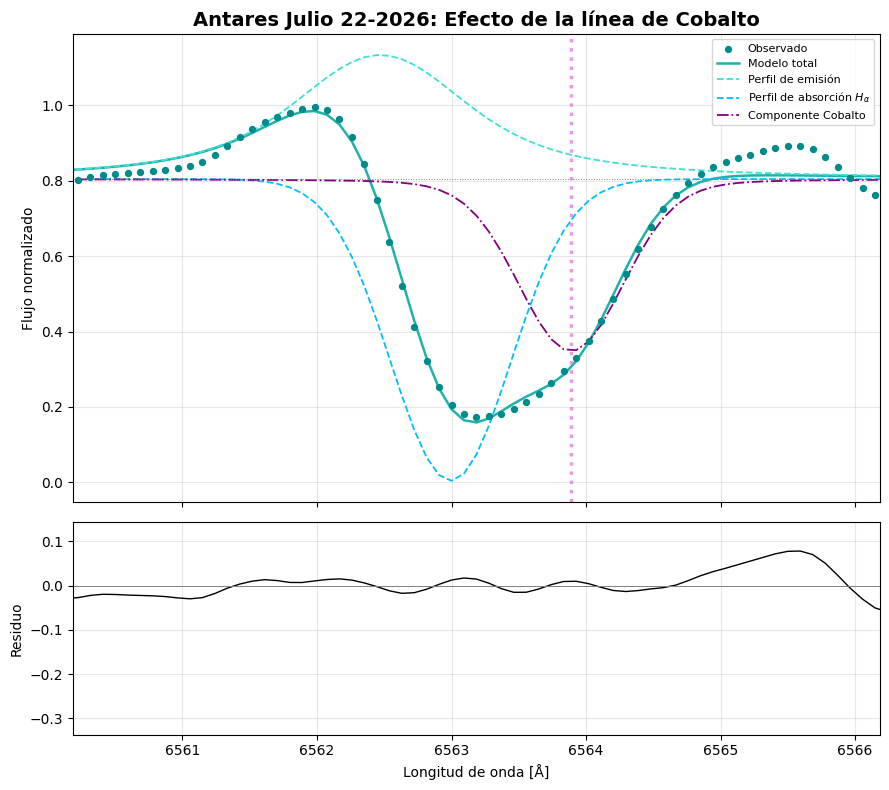

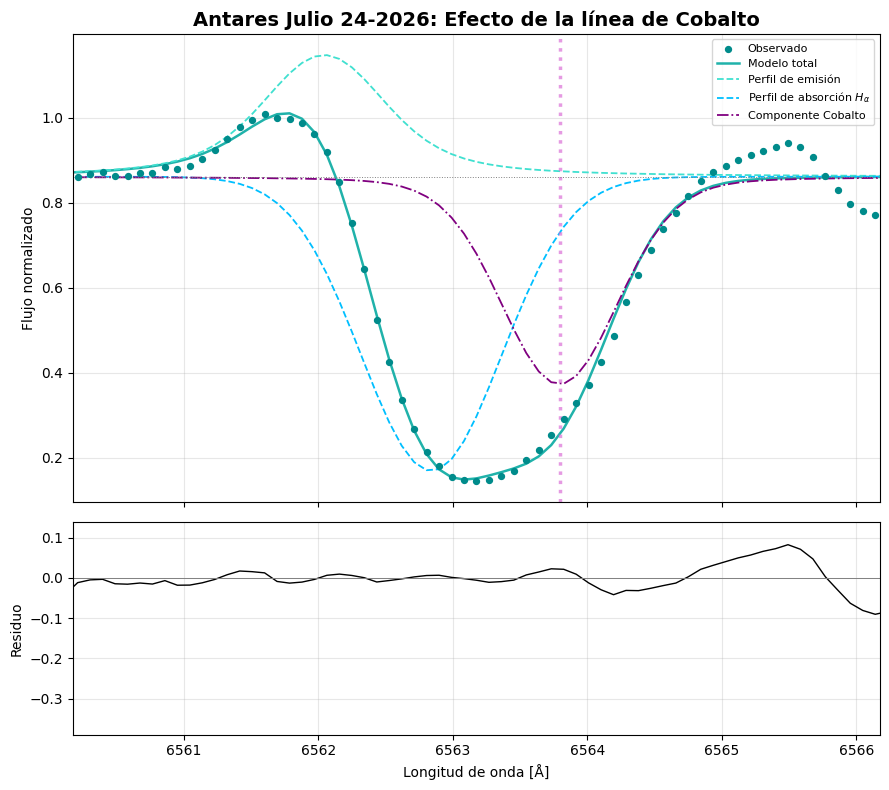

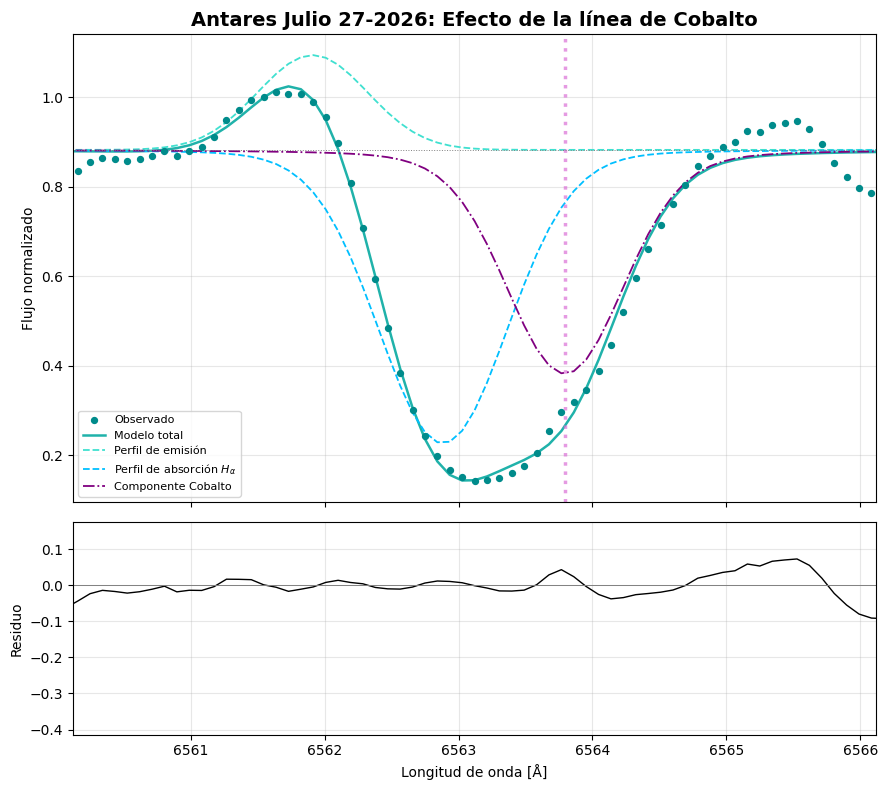

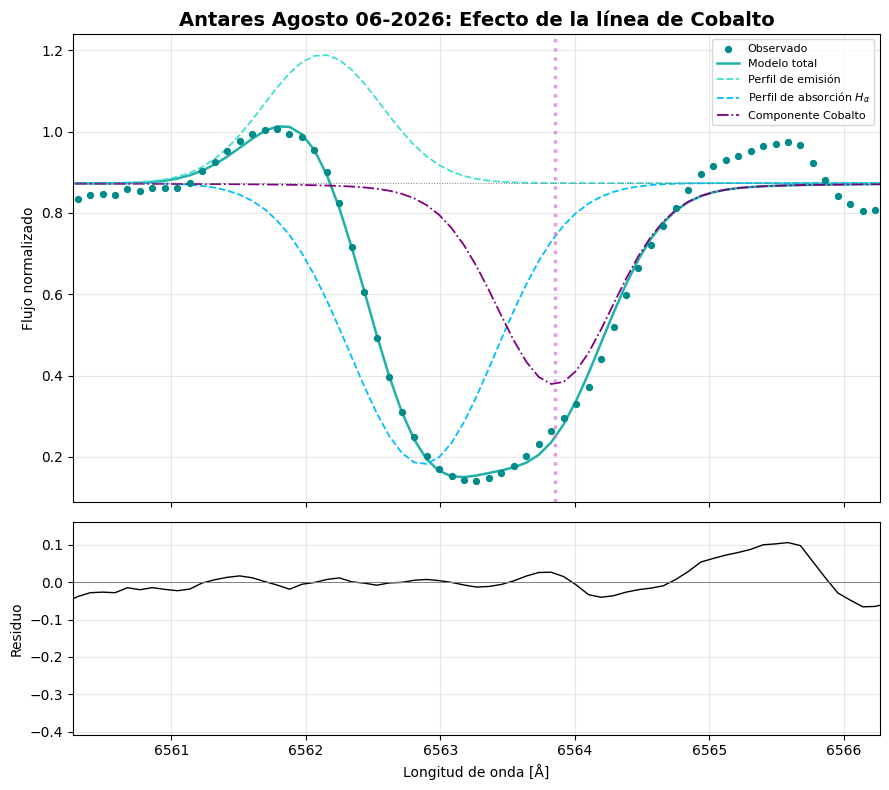

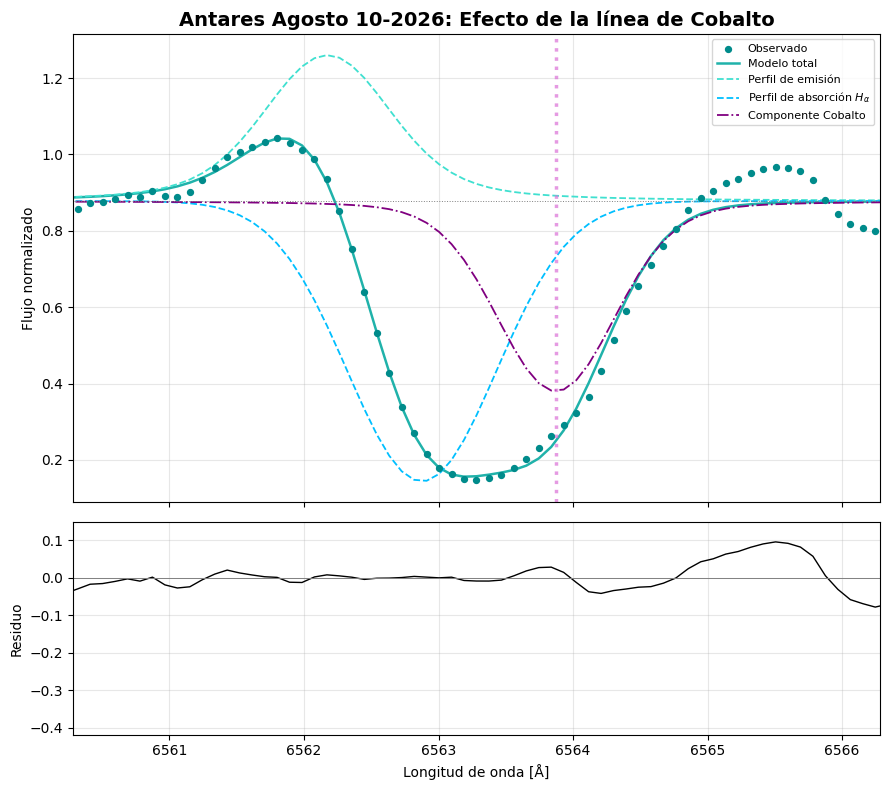

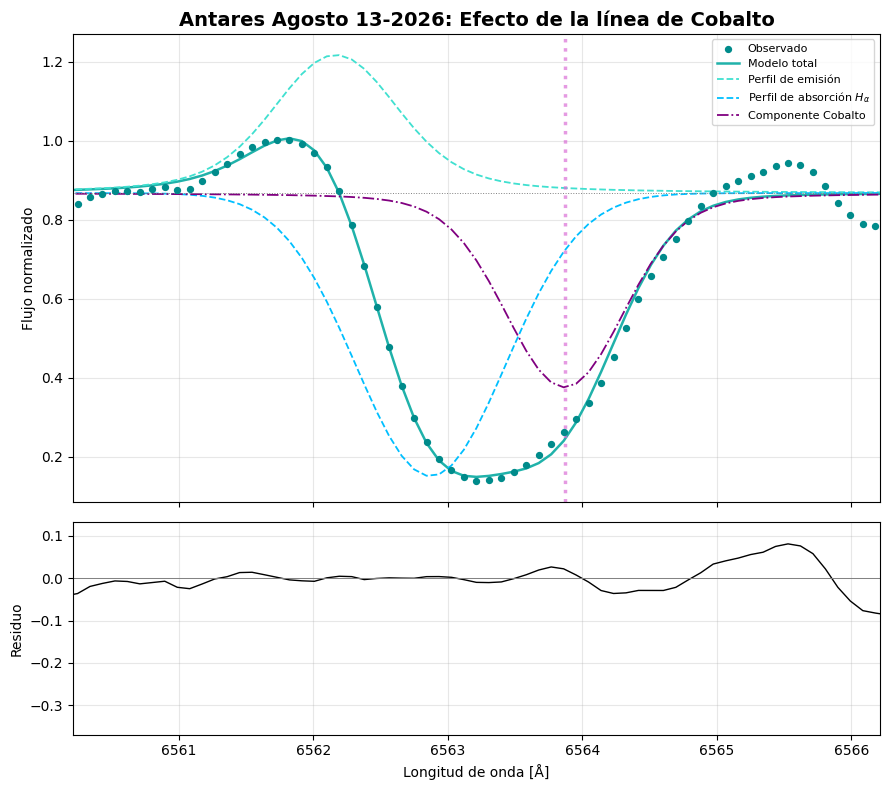

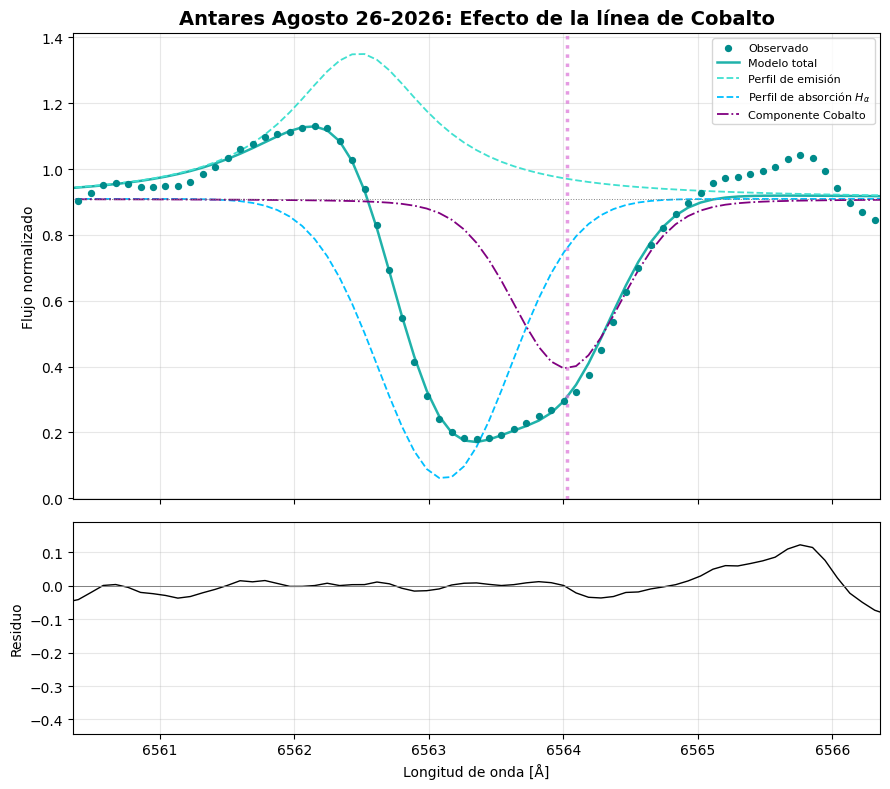

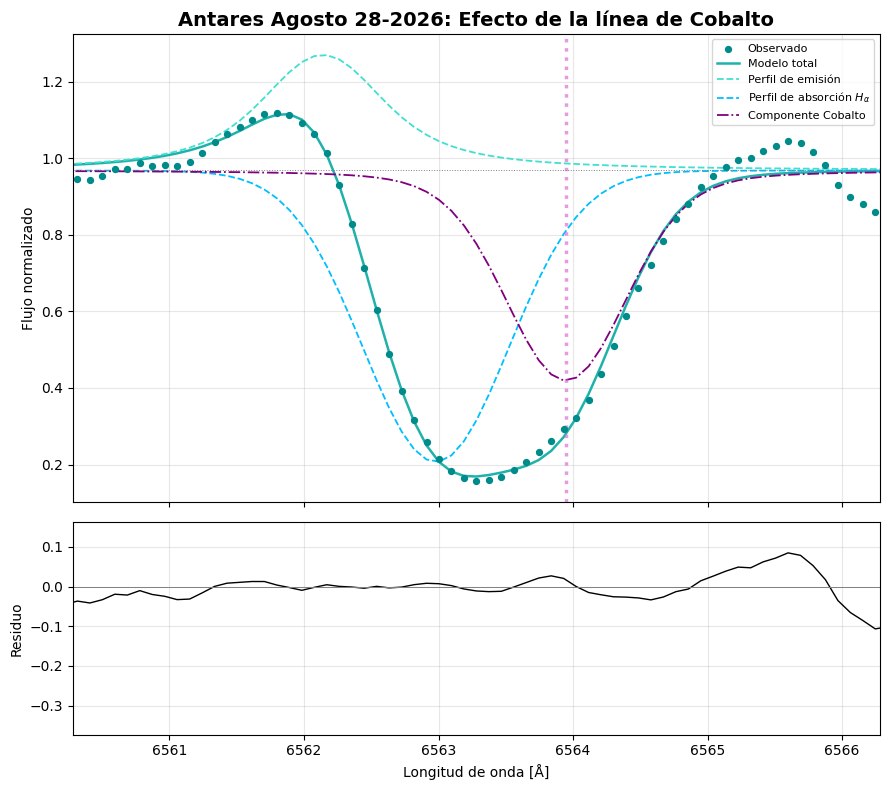

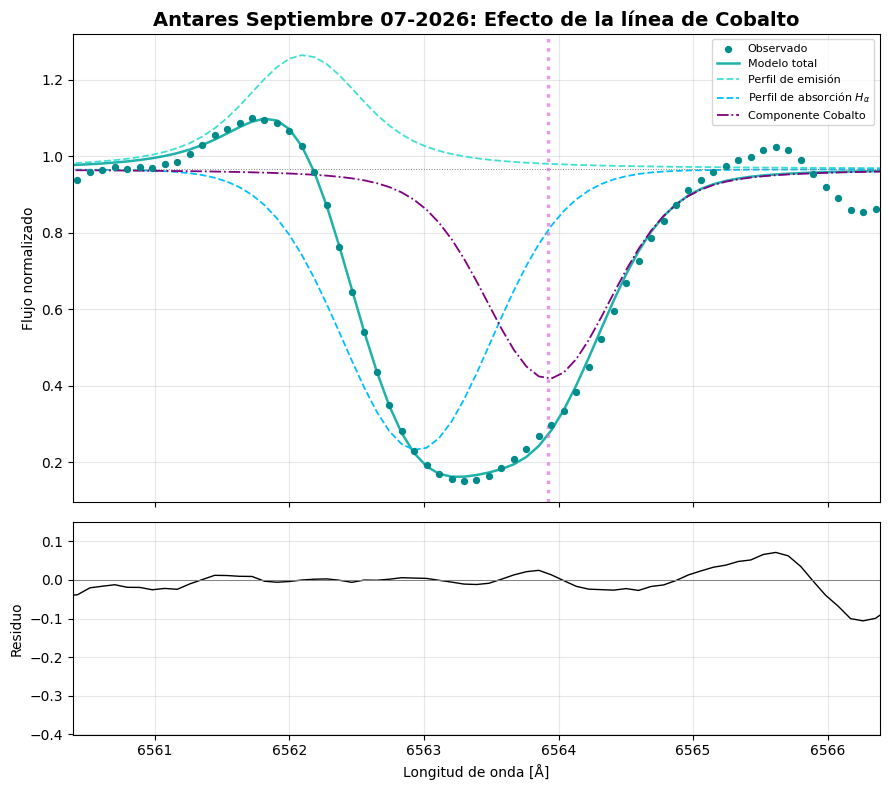

In [ ]:
# resultados = {}  

# for archivo in archivos:
    
#     fecha = archivo["fecha"]

#     lineas_metalicas = [
#         {
#             "nombre": "Cobalto",
#             "centro": 6563.397,
#             "ion": "Co I",
#             "velocidad": archivo["velocidad_metalica"],
#             "incertidumbre_v": archivo["incertidumbre_v"],
#             "prof_ref": (0.55, 0.63),
#             "t_ref": (3500, 4250),
#         }
#     ]

#     res = fit_y_decomposicion(archivo["datos"], archivo["centro_aprox"],
#             "Longitud onda", "Flujo Normalizado", lineas_metalicas=lineas_metalicas, teff=3660, ventana_vecinos=archivo["ventana_vecinos"],)

#     resultados[fecha] = res

#     visualizacion_con_metalica(res, lineas_metalicas, fecha,titulo=f"Antares {fecha}: Efecto de la línea de Cobalto", 
#                                rango_x=(archivo["centro_aprox"] - 3, archivo["centro_aprox"] + 3))

<h5 style="color: #e19edc;"> Gráfica Conjunta</sub></h5>

In [27]:
def _dibujar_panel(ax, ax2, res_metal, lineas_metalicas, titulo, rango_x=None):

    longitud_onda = res_metal["longitud_onda"]
    flujo = res_metal["flujo"]
    fit = res_metal["fit"]
    comps = res_metal["comps"]
    continuo = comps["cont_"]

    ax.tick_params(labelbottom=False)

    # Panel Superior
    ax.scatter(longitud_onda, flujo, s=18, color="darkcyan", label="Observado", zorder=3)
    ax.plot(longitud_onda, fit.best_fit, color="lightseagreen", lw=1.8, label="Modelo total")
    ax.plot(longitud_onda, res_metal["perfil_emision"], "--", color="turquoise", lw=1.3, label="Perfil de emisión")
    ax.plot(longitud_onda, res_metal["perfil_absorcion"], "--", color="deepskyblue", lw=1.3,
            label=r"Perfil de absorción $H_\alpha$")

    for linea in lineas_metalicas:
        pref = f"{linea['nombre']}_"
        perfil_metal = continuo + comps[pref]
        ax.plot(longitud_onda, perfil_metal, "-.", color="purple", lw=0.7, label=f"Componente {linea['nombre']}")
        ax.axvline(fit.params[f"{pref}center"].value, color="orchid", lw=2.5, ls=":", alpha=0.7)

    # Continuo
    ax.axhline(continuo[0], color="gray", lw=0.7, ls=":")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=6)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

    # Panel de residuo
    ax2.plot(longitud_onda, res_metal["residuo"], color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel("Longitud de onda [Å]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    if rango_x is not None:
        ax.set_xlim(rango_x)

    return ax, ax2


def _margen_superior(alto_fig, margen_titulo_in=0.65, margen_superior_in=0.15):

    top = 1 - margen_titulo_in / alto_fig
    y_supertitulo = 1 - margen_superior_in / alto_fig
    return top, y_supertitulo


def _distribuir_fila(gs, fila, n_columnas, n_items):

    lado = (n_columnas - n_items) / 2

    if lado > 0:
        fila_gs = gs[fila, :].subgridspec(1, 3, width_ratios=[lado, n_items, lado], wspace=0.0)
        centro = fila_gs[1]
    else:
        centro = gs[fila, :]

    sub_fila = centro.subgridspec(1, n_items, wspace=0.15)

    slots = [sub_fila[j].subgridspec(2, 1, height_ratios=[2.2, 1], hspace=0.05) for j in range(n_items)]
    return slots

In [28]:
def crear_figura(anio, fechas_bloque, datos_anio, carpeta_salida=None, n_columnas=2,
                  ancho_por_columna=8.0, alto_por_fila=5.5, sufijo=""):

    n_items = len(fechas_bloque)

    if n_items == 0:
        return None

    n_filas = int(np.ceil(n_items / n_columnas))

    ancho_fig = ancho_por_columna * n_columnas
    alto_fig = alto_por_fila * n_filas

    fig = plt.figure(figsize=(ancho_fig, alto_fig))
    gs = GridSpec(n_filas, n_columnas, figure=fig, hspace=0.45, wspace=0.15)

    for fila in range(n_filas):

        idx_inicio = fila * n_columnas
        idx_fin = min(idx_inicio + n_columnas, n_items)
        items_fila = fechas_bloque[idx_inicio:idx_fin]

        slots = _distribuir_fila(gs, fila, n_columnas, len(items_fila))

        for slot, fecha in zip(slots, items_fila):

            datos = datos_anio[fecha]["Hα"]

            ax = fig.add_subplot(slot[0])
            ax2 = fig.add_subplot(slot[1], sharex=ax)

            _dibujar_panel(ax, ax2, datos["res"], datos["lineas"], datos["titulo"], datos["rango_x"])

    top, y_sup = _margen_superior(alto_fig)

    titulo_fig = fr"Modelamiento sector Hα — {anio}" + (f" ({sufijo.strip('_').replace('parte', 'parte ')})"
                                                          if sufijo else "")

    fig.suptitle(titulo_fig, fontsize=18, fontweight="bold", y=y_sup)
    fig.subplots_adjust(top=top, bottom=0.04, left=0.05, right=0.98, hspace=0.45, wspace=0.15)

    if carpeta_salida is not None:
        ruta = (carpeta_salida + fr"\comparacion_sector_Halpha_{anio}{sufijo}.png")
        fig.savefig(ruta, dpi=300, bbox_inches="tight")
        print(fr"Figura {anio}{sufijo} guardada en:\n{ruta}")

    plt.show()
    return fig

In [29]:
def generar_figuras_anio(anio, datos_anio, carpeta_salida=None, n_columnas=2, max_filas=4, **kwargs):

    fechas_halpha = [f for f in datos_anio if "Hα" in datos_anio[f]]

    if len(fechas_halpha) == 0:
        return []

    tam_bloque = n_columnas * max_filas
    n_bloques = int(np.ceil(len(fechas_halpha) / tam_bloque))

    figuras = []

    for i in range(n_bloques):

        bloque = fechas_halpha[i * tam_bloque: (i + 1) * tam_bloque]
        sufijo = f"_parte{i + 1}" if n_bloques > 1 else ""

        fig = crear_figura(anio, bloque, datos_anio, carpeta_salida=carpeta_salida,
                            n_columnas=n_columnas, sufijo=sufijo, **kwargs)
        figuras.append(fig)

    return figuras

Figura 2024_parte1 guardada en:\nGraficas 2024, 2025 y 2026\Modelamiento\comparacion_sector_Halpha_2024_parte1.png


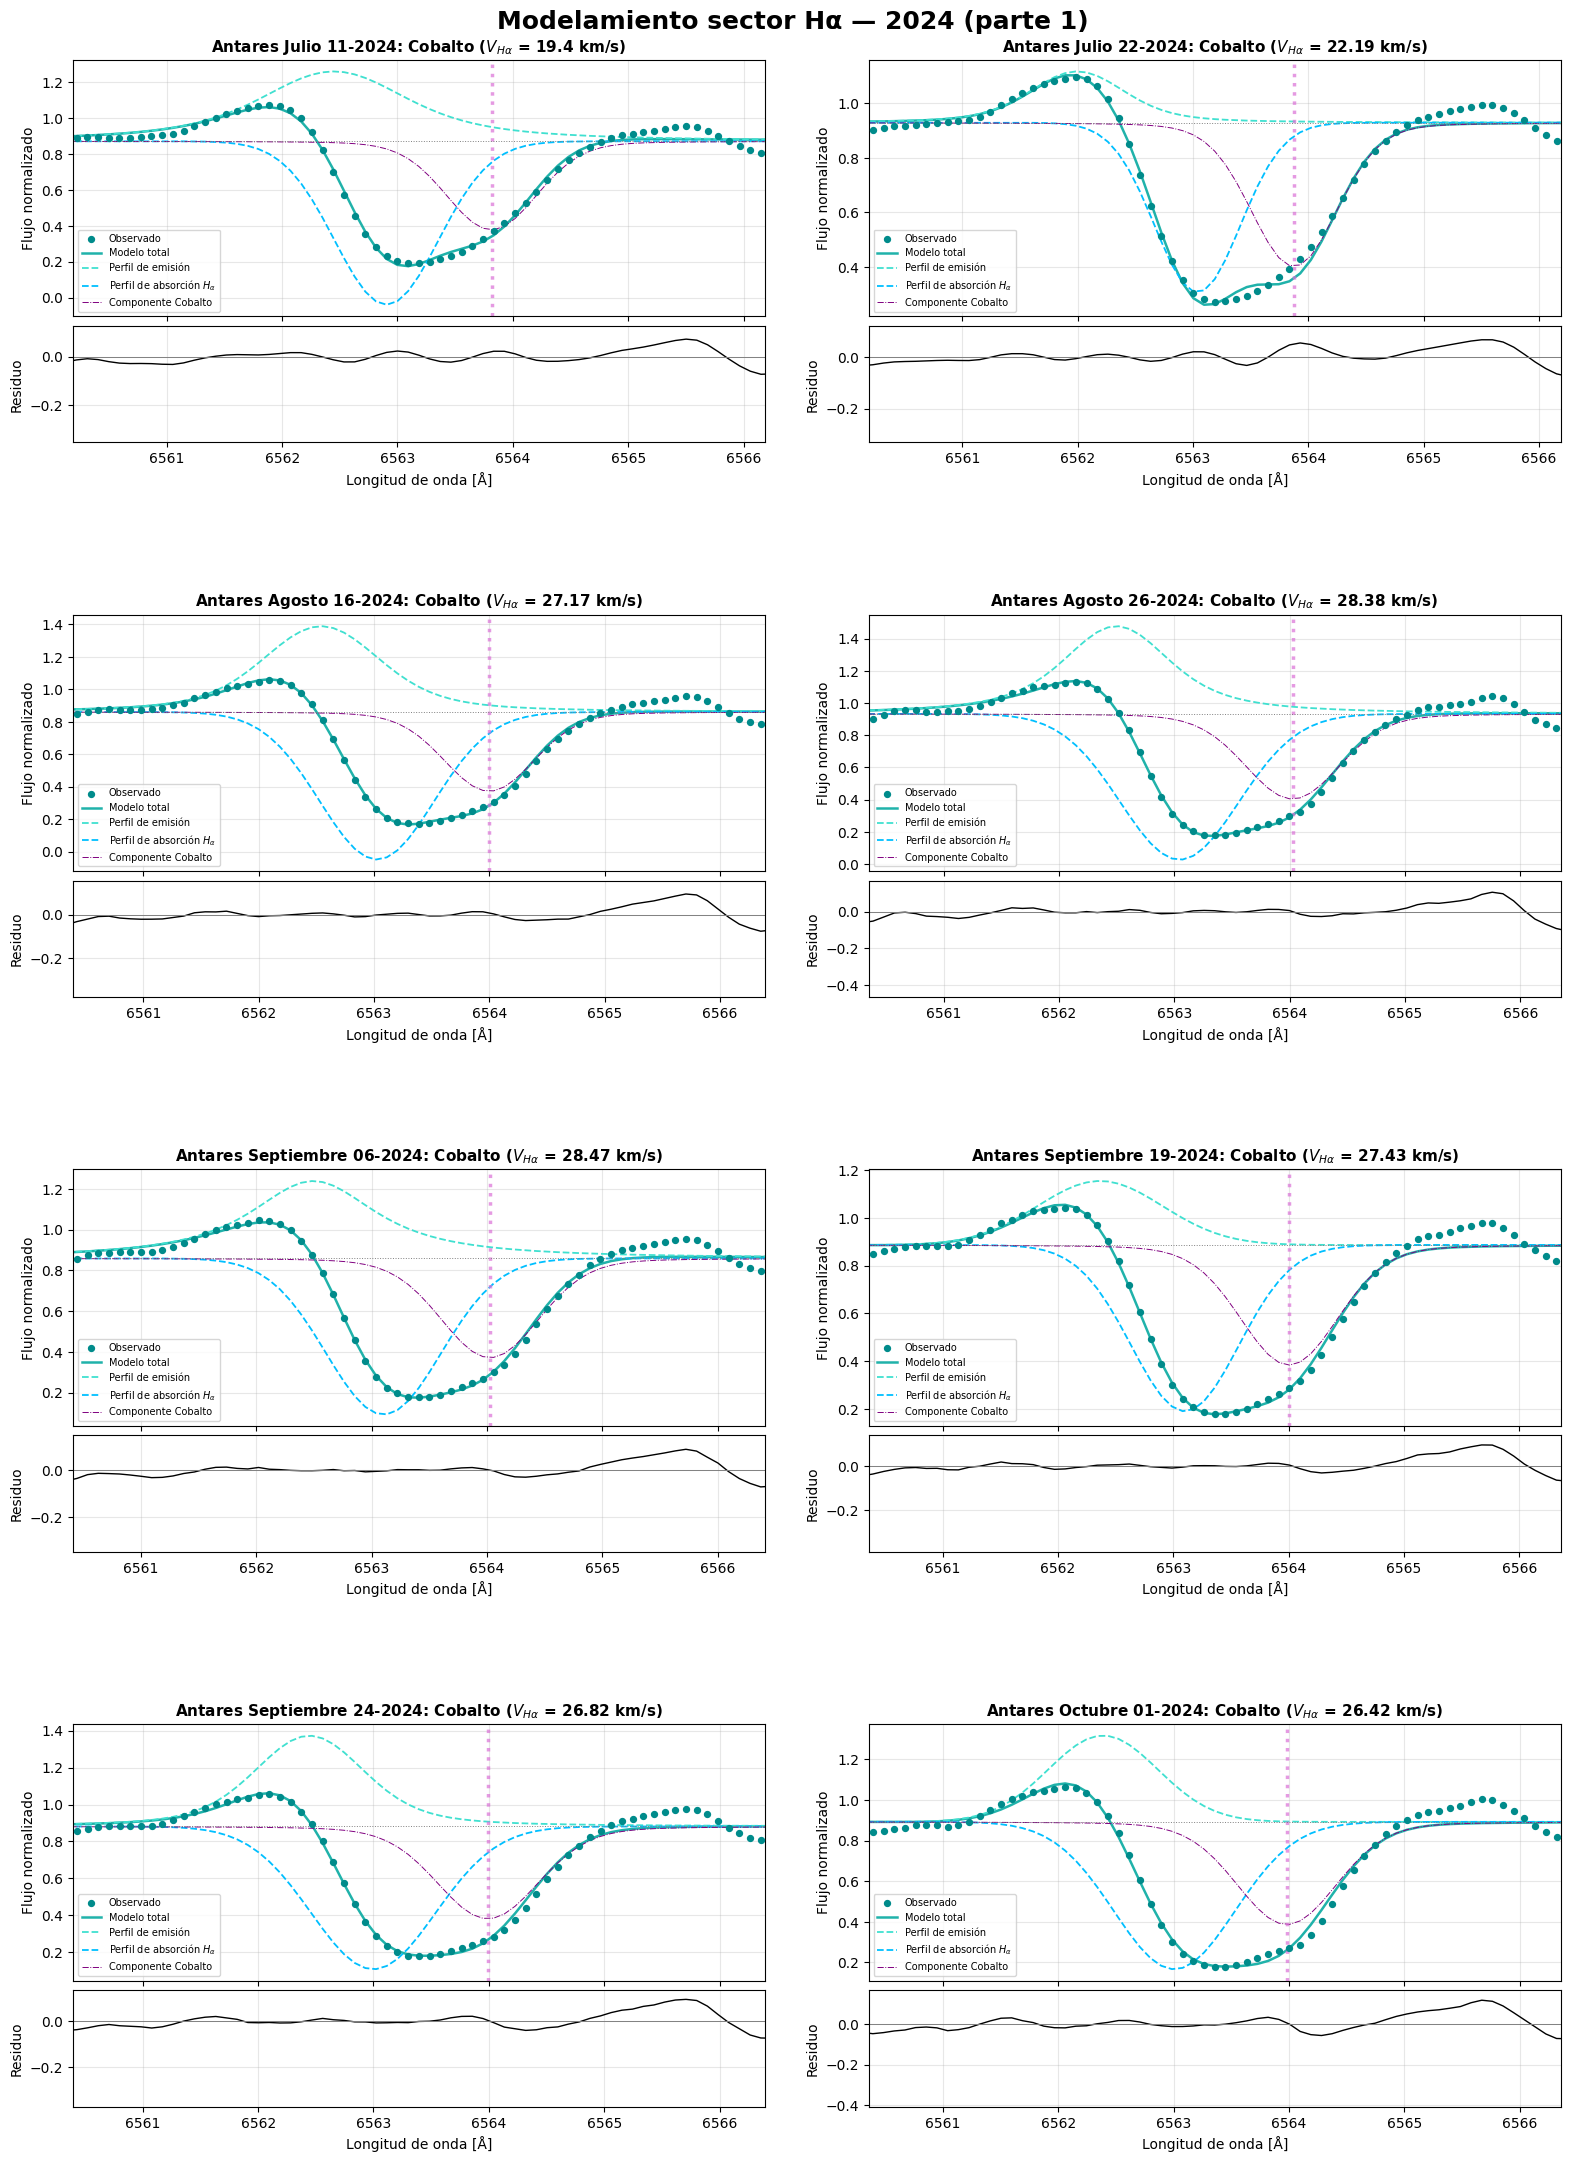

Figura 2024_parte2 guardada en:\nGraficas 2024, 2025 y 2026\Modelamiento\comparacion_sector_Halpha_2024_parte2.png


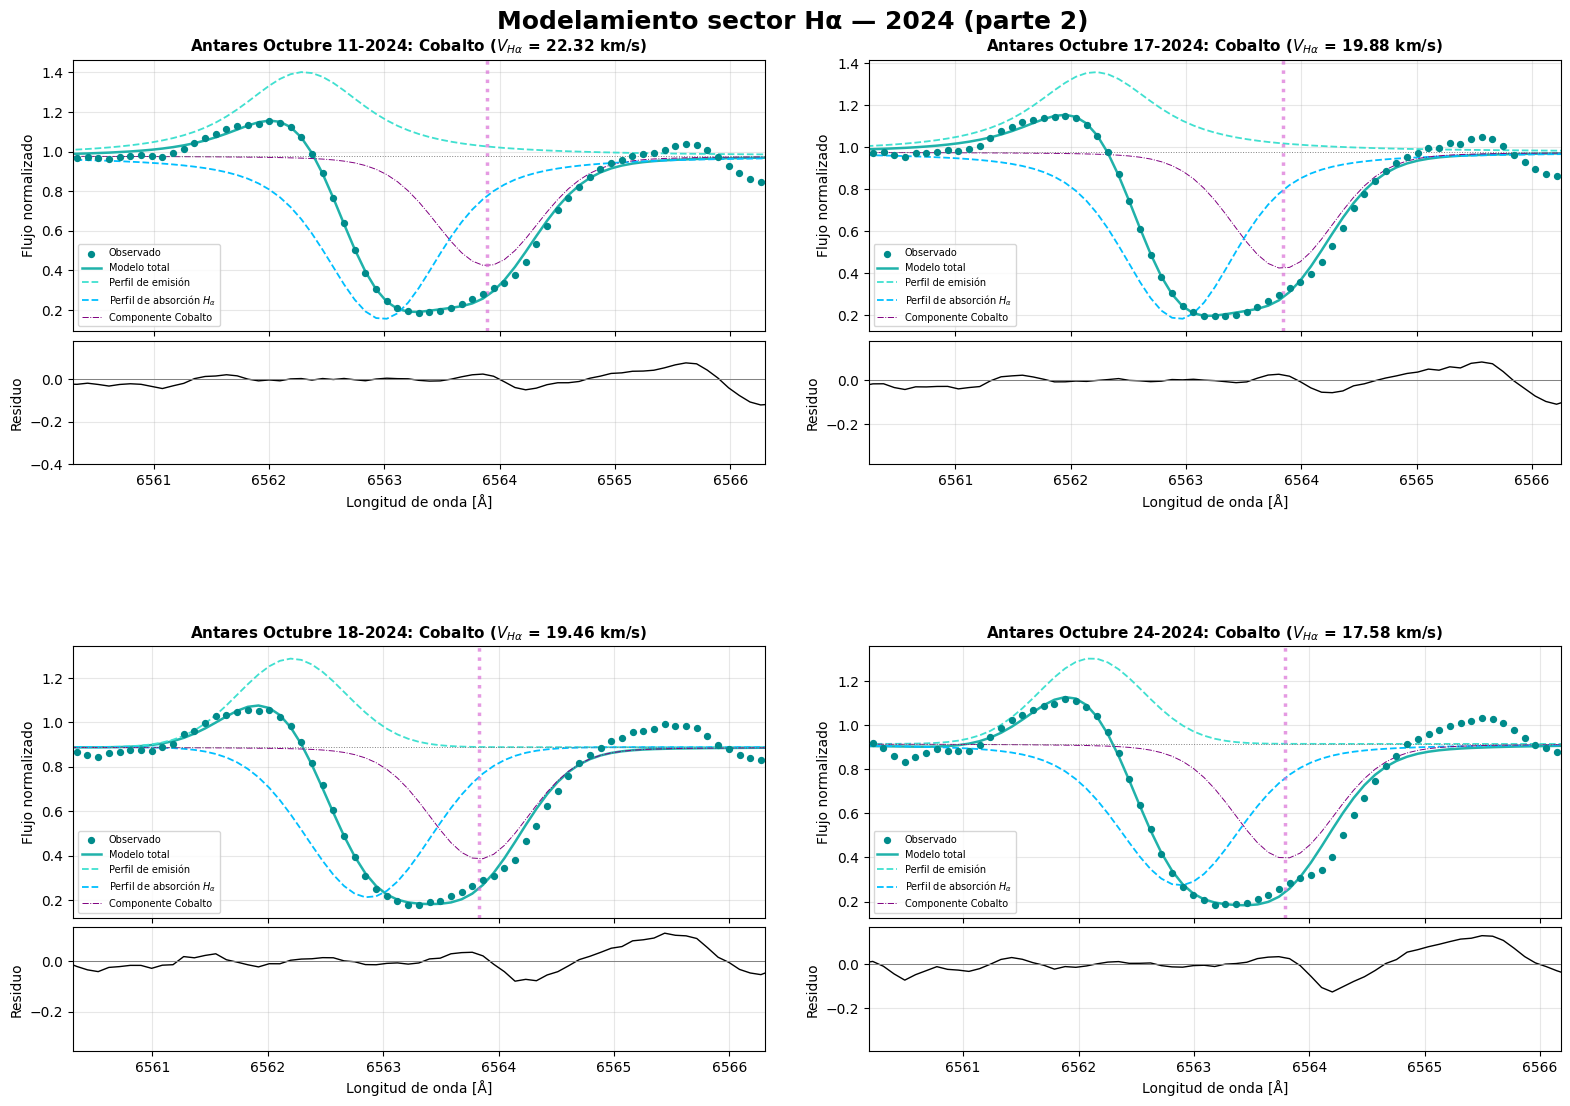

Figura 2025 guardada en:\nGraficas 2024, 2025 y 2026\Modelamiento\comparacion_sector_Halpha_2025.png


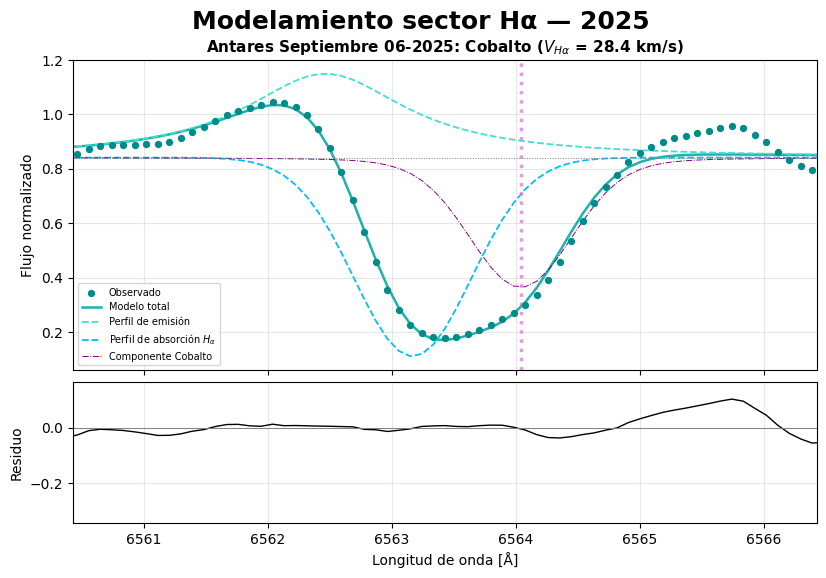

Figura 2026_parte1 guardada en:\nGraficas 2024, 2025 y 2026\Modelamiento\comparacion_sector_Halpha_2026_parte1.png


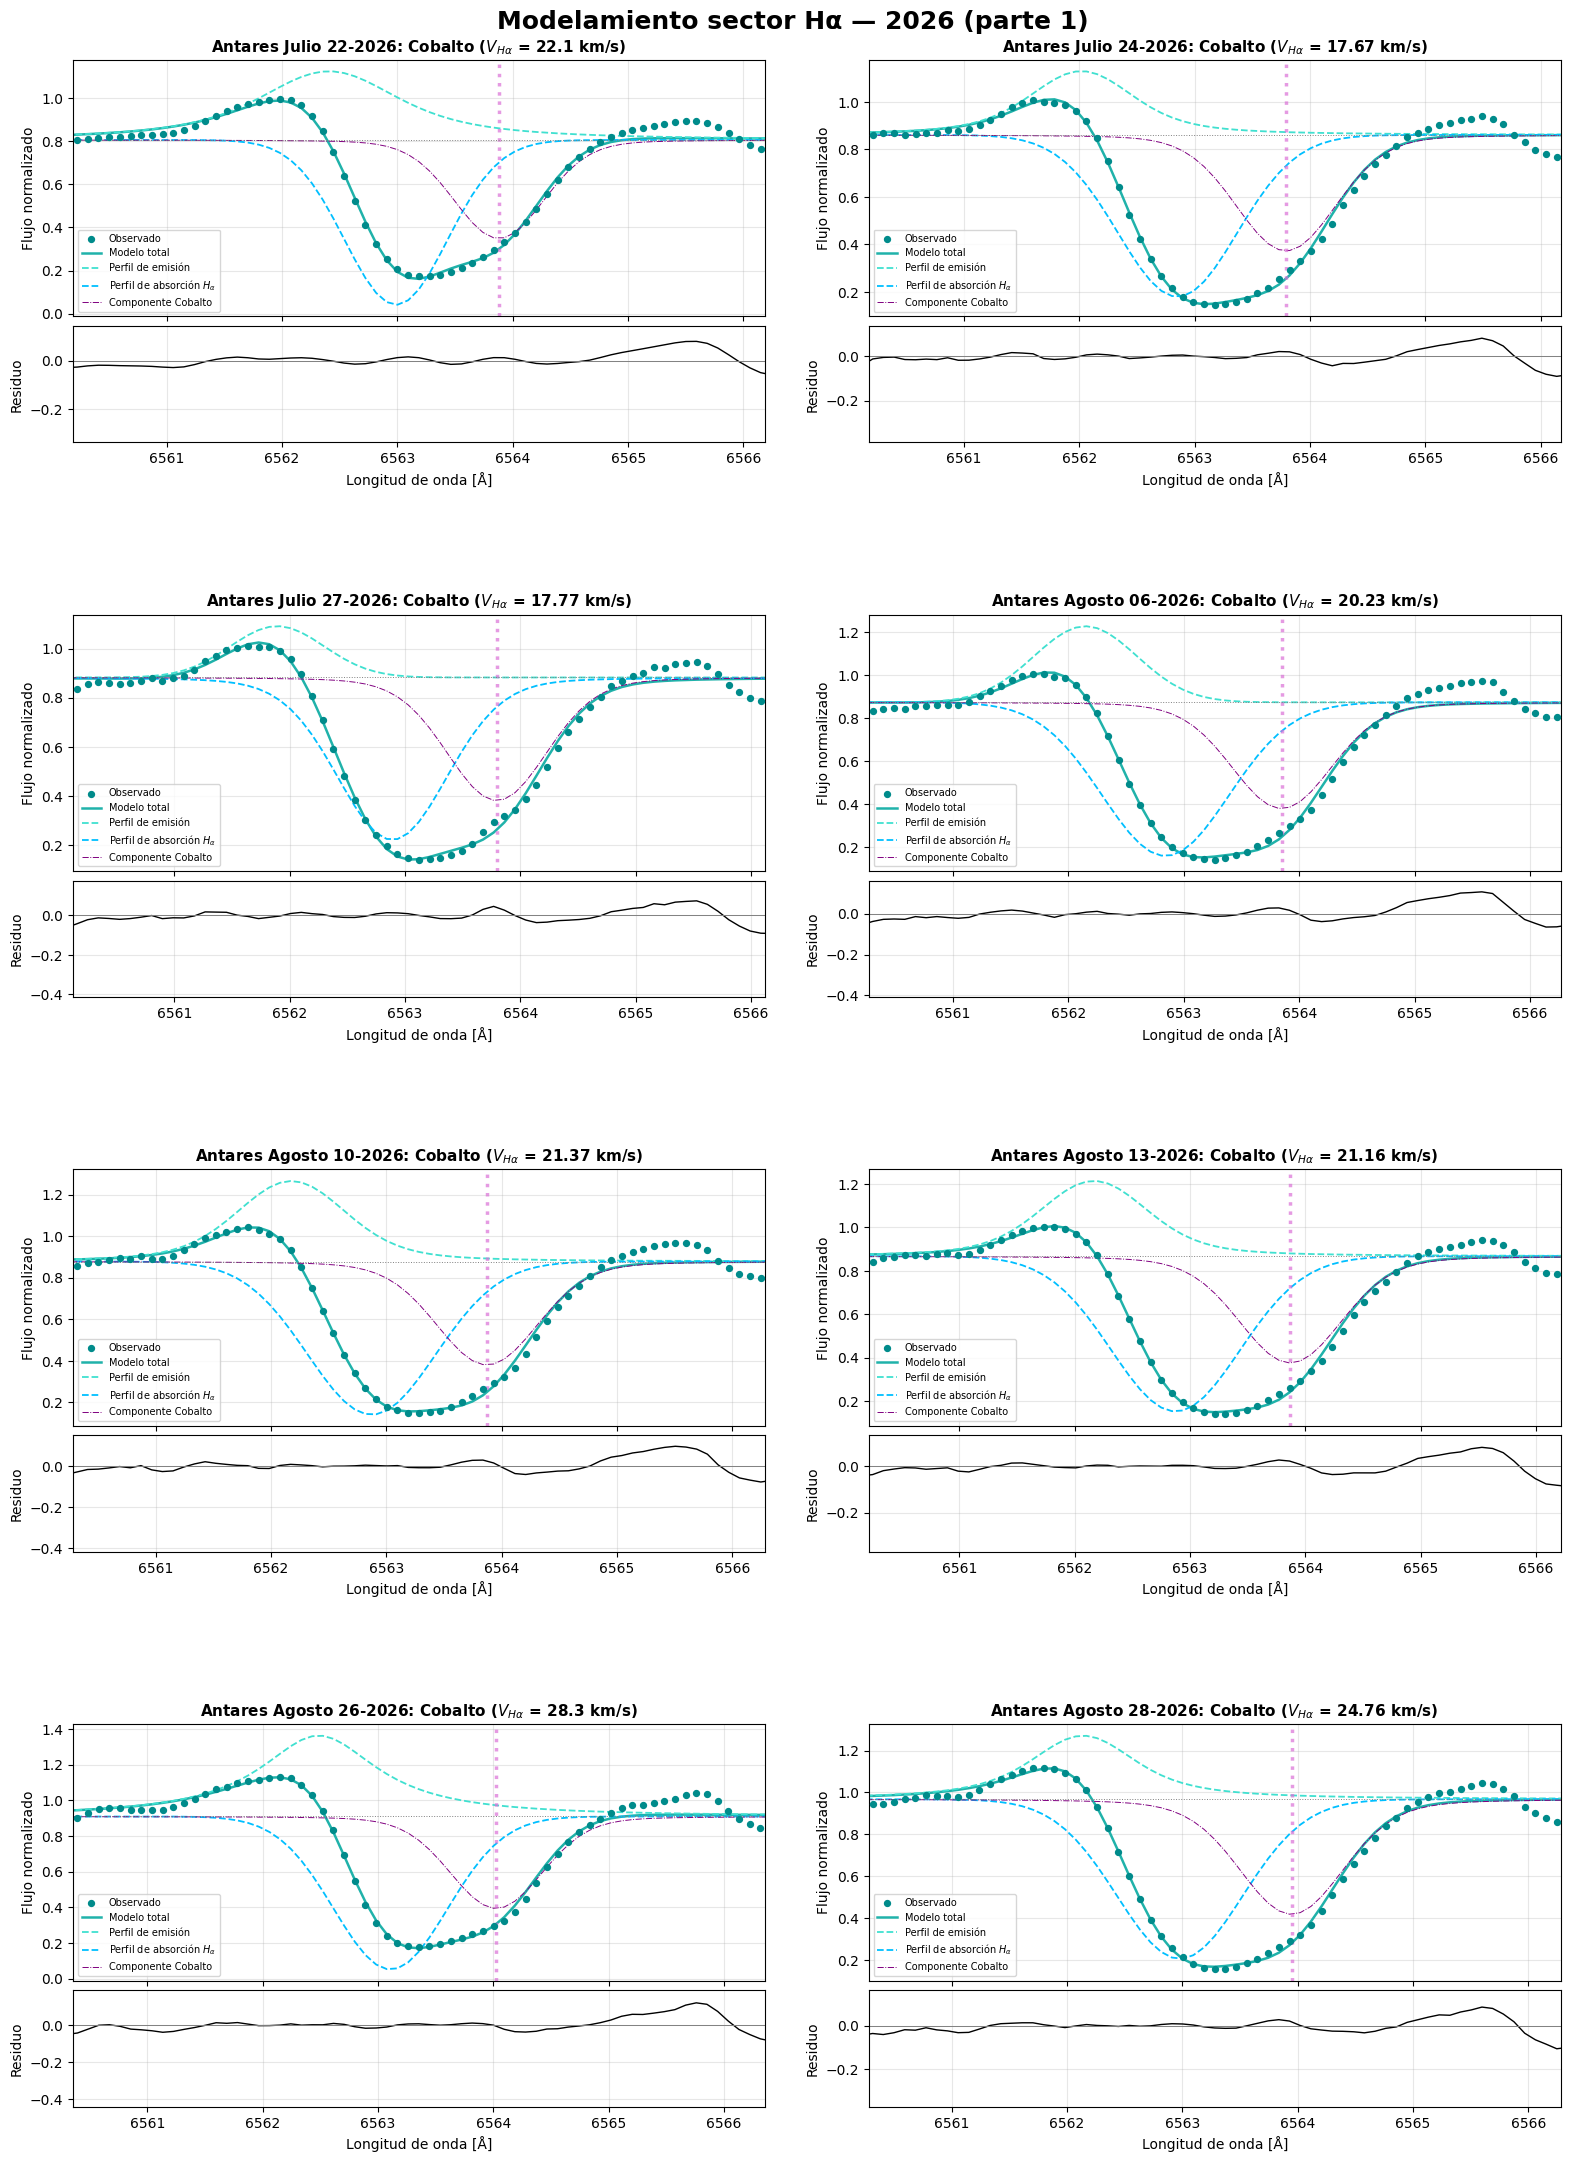

Figura 2026_parte2 guardada en:\nGraficas 2024, 2025 y 2026\Modelamiento\comparacion_sector_Halpha_2026_parte2.png


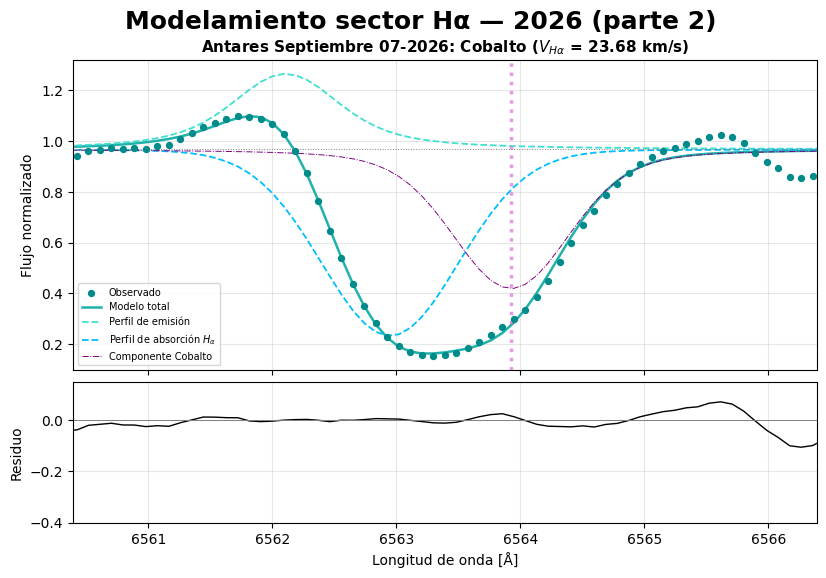

In [35]:
centro_lab_cobalto = 6563.397  # Angstroms

resultados = {}
visualizaciones_por_anio = {}

for meta in archivos:

    fecha_str = meta["fecha"]
    df = meta["datos"]
    fits_fecha = {}

    anio = fecha_str[-4:]

    visualizaciones_por_anio.setdefault(anio, {})
    visualizaciones_por_anio[anio].setdefault(fecha_str, {})

    v_halpha = meta.get("velocidad_metalica")

    if v_halpha is not None:
 
        err_halpha = meta.get("incertidumbre_v", 3.0)
 
        lineas_halpha = [{
            "nombre": "Cobalto",
            "centro": centro_lab_cobalto,
            "velocidad": v_halpha,
            "incertidumbre_v": err_halpha,
            "prof_ref": (0.55, 0.63),
            "t_ref": (3500, 4250),
        }]
 
        fits_fecha["Hα"] = fit_y_decomposicion(df, meta["centro_aprox"], "Longitud onda", "Flujo Normalizado",
                                                lineas_metalicas=lineas_halpha, teff=3660)
 
        visualizaciones_por_anio[anio][fecha_str]["Hα"] = {
            "res": fits_fecha["Hα"],
            "lineas": lineas_halpha,
            "titulo": (
                f"Antares {fecha_str}: "
                f"Cobalto "
                f"($V_{{H\\alpha}}$ = "
                f"{v_halpha} km/s)"
            ),
            "rango_x": (
                meta["centro_aprox"] - 3,
                meta["centro_aprox"] + 3
            )
        }
 
    if "Hα" in fits_fecha:
        resultados[fecha_str] = fits_fecha["Hα"]
 
carpeta_salida = (r"Graficas 2024, 2025 y 2026\Modelamiento")

for anio, datos_anio in visualizaciones_por_anio.items():
    generar_figuras_anio(anio, datos_anio, carpeta_salida=carpeta_salida, n_columnas=2, max_filas=4)

<h3 style="color: #e19edc;"> Obtención de los parámetros del ajuste de H<sub>&alpha;</sub></h3>

In [31]:
h_alpha_natural = 6562.812 # Angstroms
cobalto_natural = centro_lab_cobalto

resultados_perfiles_halpha_y_cobalto = []

for fecha, res in resultados.items():
    p = res["fit"].params
    comps = res["comps"]
    longitud_onda = res["longitud_onda"]
    continuo = comps["cont_"]
    
    # 1. PERFIL DE EMISIÓN AZUL

    c_em = p["em_azul_center"].value
    fwhm_em = p["em_azul_fwhm"].value
    amp_em = p["em_azul_height"].value 

    # Efecto Doppler (Corrimiento)
    z_em = (c_em - h_alpha_natural) / h_alpha_natural
    v_em = z_em * c_kms_s
    
    # Ancho equivalente de emisión
    perfil_em_puro = comps["em_azul_"]
    ew_em = np.trapezoid(perfil_em_puro / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha,
        "Componente": "Emisión Azul Hα",
        "Centro [Å]": round(c_em, 3),
        "z": round(z_em, 6),
        "Velocidad [km/s]": round(v_em, 4),
        "Profundidad / Altura": round(amp_em, 4),
        "FWHM [Å]": round(fwhm_em, 3),
        "EW [Å]": round(ew_em, 4)
    })
    
    # 2. PERFIL DE ABSORCIÓN H_ALPHA
    
    c_abs = p["valle_abs_center"].value
    fwhm_abs = p["valle_abs_fwhm"].value
    prof_abs = abs(p["valle_abs_height"].value) 

    # Efecto Doppler (Corrimiento)
    z_abs = (c_abs - h_alpha_natural) / h_alpha_natural
    v_abs = z_abs * c_kms_s
    
    # Ancho equivalente de absorción
    perfil_abs_puro = comps["valle_abs_"]
    ew_abs = np.trapezoid(abs(perfil_abs_puro) / continuo, longitud_onda)
    
    resultados_perfiles_halpha_y_cobalto.append({
        "Época": fecha,
        "Componente": "Absorción Hα",
        "Centro [Å]": round(c_abs, 3),
        "z": round(z_abs, 6),
        "Velocidad [km/s]": round(v_abs, 4),
        "Profundidad / Altura": round(prof_abs, 4),
        "FWHM [Å]": round(fwhm_abs, 3),
        "EW [Å]": round(ew_abs, 4)
    })

    # 3. LÍNEA DE COBALTO

    c_co = p["Cobalto_center"].value
    fwhm_co = p["Cobalto_fwhm"].value
    prof_co = abs(p["Cobalto_height"].value)

    # Efecto Doppler (Corrimiento)
    z_co = (c_co - cobalto_natural) / cobalto_natural
    v_co = z_co * c_kms_s

    # Ancho equivalente de absorción
    perfil_co_puro = comps["Cobalto_"]
    ew_co = np.trapezoid(abs(perfil_co_puro) / continuo, longitud_onda)

    resultados_perfiles_halpha_y_cobalto.append({
            "Época": fecha,
            "Componente": "Absorción Cobalto",
            "Centro [Å]": round(c_co, 3),
            "z": round(z_co, 6),
            "Velocidad [km/s]": round(v_co, 4),
            "Profundidad / Altura": round(prof_co, 4),
            "FWHM [Å]": round(fwhm_co, 3),
            "EW [Å]": round(ew_co, 4)
        })



tabla_resultados = pd.DataFrame(resultados_perfiles_halpha_y_cobalto)
display(tabla_resultados)

,Época,Componente,Centro [Å],z,Velocidad [km/s],Profundidad / Altura,FWHM [Å],EW [Å]
0,Julio 11-2024,Emisión Azul Hα,6562.448,-0.000055,-16.6369,0.3898,1.555,0.9323
1,Julio 11-2024,Absorción Hα,6562.905,0.000014,4.2427,0.9122,1.059,1.1795
2,Julio 11-2024,Absorción Cobalto,6563.815,0.000064,19.0999,0.4944,0.927,0.5872
3,Julio 22-2024,Emisión Azul Hα,6561.996,-0.000124,-37.2771,0.1879,0.982,0.2444
4,Julio 22-2024,Absorción Hα,6563.038,0.000034,10.3394,0.6215,0.875,0.6232
...,...,...,...,...,...,...,...,...
61,Agosto 28-2026,Absorción Hα,6562.980,0.000026,7.6600,0.7614,1.282,1.0770
62,Agosto 28-2026,Absorción Cobalto,6563.948,0.000084,25.1500,0.5489,1.070,0.6982
63,Septiembre 07-2026,Emisión Azul Hα,6562.106,-0.000108,-32.2395,0.2979,1.046,0.4257
64,Septiembre 07-2026,Absorción Hα,6562.949,0.000021,6.2449,0.7348,1.307,1.0736


In [32]:
tabla_resultados.to_excel(fr"Parámetros para análisis de Antares\resultados perfiles halpha 2024, 2025 y 2026.xlsx", index=False)

In [33]:
# Tabla para Emisión Azul de Hα
tabla_emision = tabla_resultados[tabla_resultados["Componente"] == "Emisión Azul Hα"]

# Tabla para Absorción de Hα
tabla_abs_halpha = tabla_resultados[tabla_resultados["Componente"] == "Absorción Hα"]

# Tabla para Absorción de Cobalto
tabla_cobalto = tabla_resultados[tabla_resultados["Componente"] == "Absorción Cobalto"]

In [34]:
tabla_emision.to_excel(fr"Parámetros para análisis de Antares\Resultados emisión azul halpha 2024, 2025 y 2026.xlsx", index=False)
tabla_abs_halpha.to_excel(fr"Parámetros para análisis de Antares\Resultados absorción halpha 2024, 2025 y 2026.xlsx", index=False)
tabla_cobalto.to_excel(fr"Parámetros para análisis de Antares\Resultados absorción cobalto 2024, 2025 y 2026.xlsx", index=False)


<h3 style="color: #e19edc;"> Verificación de la profundidad de las líneas de absorción metálicas</sub></h3>
<h4 style="color: #e19edc;"> Hierro I (Fe I) con Cobalto (Co I)</sub></h4>

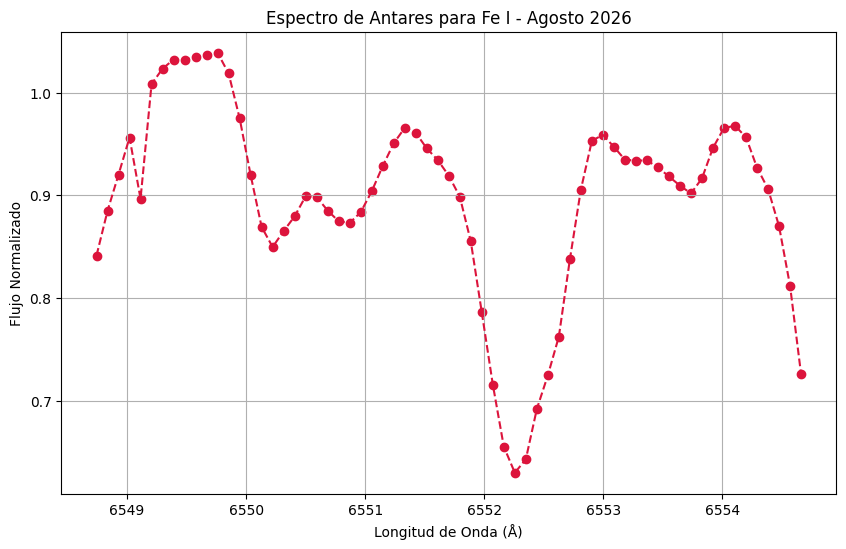

In [93]:
centro_fe = 6551.6767

indices_cercanos_agosto_fe = np.where((longitudes_observadas_agosto >= centro_fe - 3) & (longitudes_observadas_agosto <= centro_fe + 3))[0]


datos_cercanos_agosto_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_agosto[indices_cercanos_agosto_fe], 'flujo_normalizado': flujo_agosto[indices_cercanos_agosto_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_agosto_fe["longitud_observada"], datos_cercanos_agosto_fe["flujo_normalizado"], '--', color = "crimson")
plt.scatter(datos_cercanos_agosto_fe["longitud_observada"], datos_cercanos_agosto_fe["flujo_normalizado"], color = "crimson")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Agosto 2026")
plt.grid(True)
plt.show()

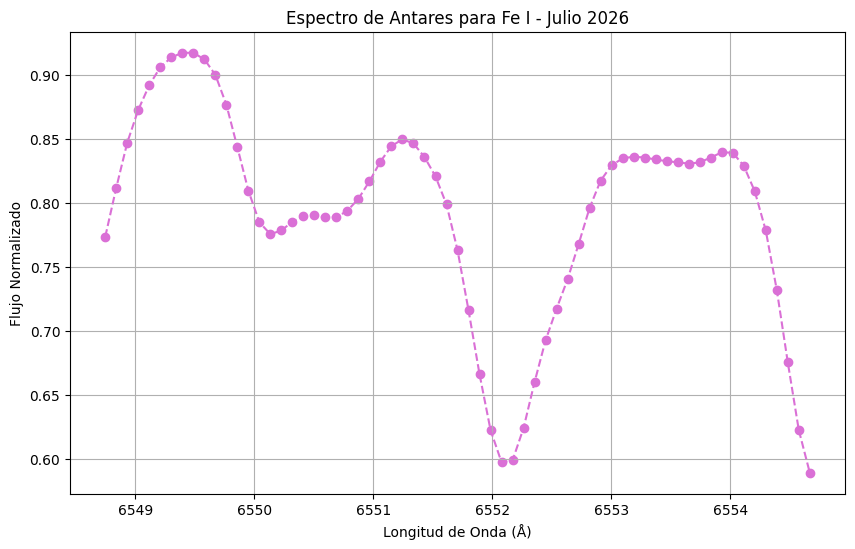

In [94]:
indices_cercanos_julio_fe = np.where((longitudes_observadas_julio >= centro_fe - 3) & (longitudes_observadas_julio <= centro_fe + 3))[0]


datos_cercanos_julio_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_julio[indices_cercanos_julio_fe], 'flujo_normalizado': flujo_julio[indices_cercanos_julio_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_julio_fe["longitud_observada"], datos_cercanos_julio_fe["flujo_normalizado"], '--', color = "orchid")
plt.scatter(datos_cercanos_julio_fe["longitud_observada"], datos_cercanos_julio_fe["flujo_normalizado"], color = "orchid")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Julio 2026")
plt.grid(True)
plt.show()

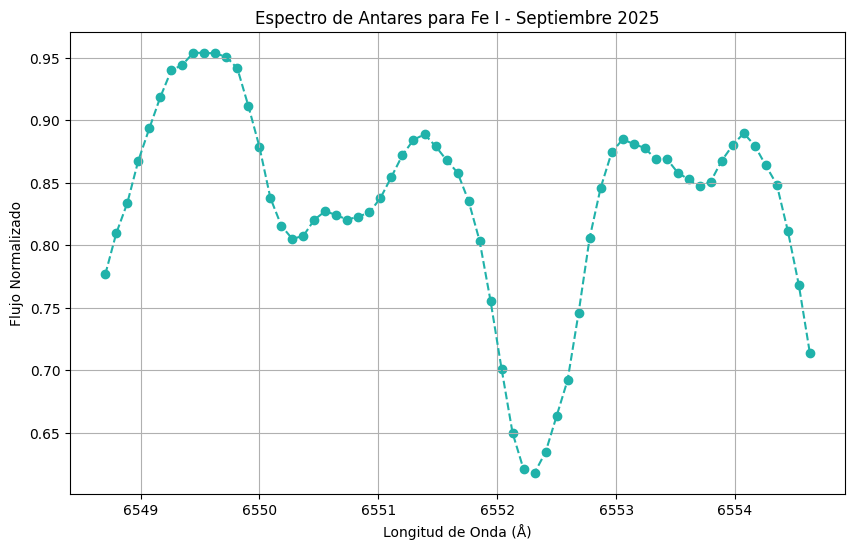

In [95]:
indices_cercanos_septiembre_fe = np.where((longitudes_observadas_septiembre >= centro_fe - 3) & (longitudes_observadas_septiembre <= centro_fe + 3))[0]


datos_cercanos_septiembre_fe = pd.DataFrame({'longitud_observada': longitudes_observadas_septiembre[indices_cercanos_septiembre_fe], 'flujo_normalizado': flujo_septiembre[indices_cercanos_septiembre_fe]})

plt.figure(figsize=(10, 6))
plt.plot(datos_cercanos_septiembre_fe["longitud_observada"], datos_cercanos_septiembre_fe["flujo_normalizado"], '--', color = "lightseagreen")
plt.scatter(datos_cercanos_septiembre_fe["longitud_observada"], datos_cercanos_septiembre_fe["flujo_normalizado"], color = "lightseagreen")

plt.xlabel("Longitud de Onda (Å)")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro de Antares para Fe I - Septiembre 2025")
plt.grid(True)
plt.show()

<h5 style="color: #e19edc;"> Construcción del modelo </h5>

In [96]:
def construccion_modelo_fe(nombre="fe1"):
    continuo = ConstantModel(prefix="cont_")
    linea_fe = VoigtModel(prefix=f"{nombre}_")
    return continuo + linea_fe


# Parámetros de Fe I
def encontrar_parametros_fe(modelo, longitud_onda, flujo, centro_lab, velocidad, incertidumbre_v, 
                            continuo_func=None, sigma_instrumental=None, gamma_instrumental=None, nombre="fe1"):
    p = modelo.make_params()

    # Cálculo del centro observado esperado
    c0_obs = efecto_doppler(centro_lab, velocidad)
    
    # Continuo Local de Halpha
    if continuo_func is not None:
        continuo_local = float(continuo_func(c0_obs))
    else:
        borde = np.r_[flujo[:5], flujo[-5:]]
        continuo_local = float(np.median(borde))

    p["cont_c"].set(value=continuo_local, min=continuo_local * 0.8, max=continuo_local * 1.2)

    margen_aa = centro_lab * incertidumbre_v / c_kms_s
    p[f"{nombre}_center"].set(value=c0_obs, min=c0_obs - margen_aa, max=c0_obs + margen_aa)

    if sigma_instrumental is not None:
        p[f"{nombre}_sigma"].set(value=sigma_instrumental, vary=False)
    else:
        p[f"{nombre}_sigma"].set(value=0.12, min=0.02, max=0.4)

    if gamma_instrumental is not None:
        p[f"{nombre}_gamma"].set(value=gamma_instrumental, vary=False)
    else:
        p[f"{nombre}_gamma"].set(value=0.05, min=0, max=0.3)

    i_min = np.argmin(flujo)
    amp0 = -(continuo_local - flujo[i_min]) * 1.2
    p[f"{nombre}_amplitude"].set(value=amp0, min=amp0 * 3, max=0)

    return p

In [97]:
def fit_fe1(datos_fe, longitud_observada, flujo_normalizado, centro_lab, velocidad, incertidumbre_v, 
            continuo_func=None, sigma_instrumental=None, gamma_instrumental=None, pesos=None, nombre="fe1"):

    longitud_onda = datos_fe[longitud_observada].to_numpy()
    flujo = datos_fe[flujo_normalizado].to_numpy()

    modelo = construccion_modelo_fe(nombre)
    parametros = encontrar_parametros_fe(
        modelo, longitud_onda, flujo, centro_lab, velocidad, incertidumbre_v,
        continuo_func=continuo_func,
        sigma_instrumental=sigma_instrumental, gamma_instrumental=gamma_instrumental, nombre=nombre
    )

    kwargs_fit = dict(x=longitud_onda, nan_policy='omit')
    if pesos is not None:
        kwargs_fit["weights"] = pesos

    fit = modelo.fit(flujo, parametros, **kwargs_fit)

    amp = fit.params[f"{nombre}_amplitude"].value
    amp_err = fit.params[f"{nombre}_amplitude"].stderr or np.nan
    sigma_fit = fit.params[f"{nombre}_sigma"].value
    gamma_fit = fit.params[f"{nombre}_gamma"].value
    continuo_fit = fit.params["cont_c"].value

    z = 1j * gamma_fit / (sigma_fit * np.sqrt(2))
    pico_unitario = wofz(z).real / (sigma_fit * np.sqrt(2 * np.pi))

    profundidad_fit = -amp * pico_unitario / continuo_fit
    profundidad_err = abs(amp_err * pico_unitario / continuo_fit) if not np.isnan(amp_err) else np.nan

    return dict(
        fit=fit,
        longitud_onda=longitud_onda,
        flujo=flujo,
        profundidad_fit=profundidad_fit,
        profundidad_err=profundidad_err,
        continuo_func=continuo_func)

In [98]:
archivos_fe = [
    {
        "fecha": "Julio 22-2026",
        "datos": datos_cercanos_julio_fe,
        "velocidad_metalica": 22.1,
        "incertidumbre_v": 0.9,
    },
    {
        "fecha": "Agosto 26-2026",
        "datos": datos_cercanos_agosto_fe,
        "velocidad_metalica": 28.3,
        "incertidumbre_v": 0.4,
    },
    {
        "fecha": "Septiembre 06-2025",
        "datos": datos_cercanos_septiembre_fe,
        "velocidad_metalica": 28.4,
        "incertidumbre_v": 0.9,
    },
]


resultados_fe = {}

for archivo in archivos_fe:
    fecha = archivo["fecha"]

    # Se extrae el continuo del ajuste de Halpha
    cont_func_halpha = resultados[fecha].get("continuo_func", None)

    res_fe = fit_fe1(
        datos_fe=archivo["datos"],
        longitud_observada="longitud_observada",
        flujo_normalizado="flujo_normalizado",
        centro_lab=centro_fe,
        velocidad=archivo["velocidad_metalica"],
        incertidumbre_v=archivo["incertidumbre_v"],
        continuo_func=cont_func_halpha
    )

    resultados_fe[fecha] = res_fe

<h5 style="color: #e19edc;"> Gráficas Individuales</sub></h5>

In [ ]:
# def visualizacion_fe(res_fe, fecha):

#     longitud_onda = res_fe["longitud_onda"]
#     flujo = res_fe["flujo"]
#     fit = res_fe["fit"]

#     comps = fit.eval_components(x=longitud_onda)

#     continuo = comps["cont_"]
#     # Sumar el continuo para proyectar la línea en y cerca a 1
#     perfil_fe = continuo + comps["fe1_"]

#     # Modelo total
#     modelo_total = fit.best_fit

#     # Residuo
#     residuo = flujo - modelo_total

#     # Figura con relación de aspecto adaptada
#     fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, 
#                              gridspec_kw={"height_ratios": [2.2, 1]})
    
#     ax = axes[0]

#     # Datos observados
#     ax.scatter(longitud_onda, flujo, s=18, color="deeppink", label="Observado", zorder=3)

#     # Continuo
#     ax.plot(longitud_onda, continuo, "--", color="gray", lw=1.2, label="Continuo")

#     # Componente Fe sola
#     ax.plot(longitud_onda, perfil_fe, "--", color="darkviolet", lw=1.5, label="Perfil Fe I")

#     ax.set_ylabel("Flujo normalizado")
#     ax.set_title(f"Ajuste de Fe I — {fecha}", fontsize=14, fontweight="bold")
#     ax.legend(fontsize=8)
#     ax.grid(alpha=0.3)

#     ax2 = axes[1]

#     ax2.plot(longitud_onda, residuo, color="black", lw=1)
#     ax2.axhline(0, color="gray", lw=0.7)
#     ax2.set_xlabel(r"Longitud de onda [$\mathrm{\AA}$]")
#     ax2.set_ylabel("Residuo")
#     ax2.grid(alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(fr"Graficas 2025 y 2026\Hierro\Fe_I_{fecha}.png", dpi=150)
#     plt.show()

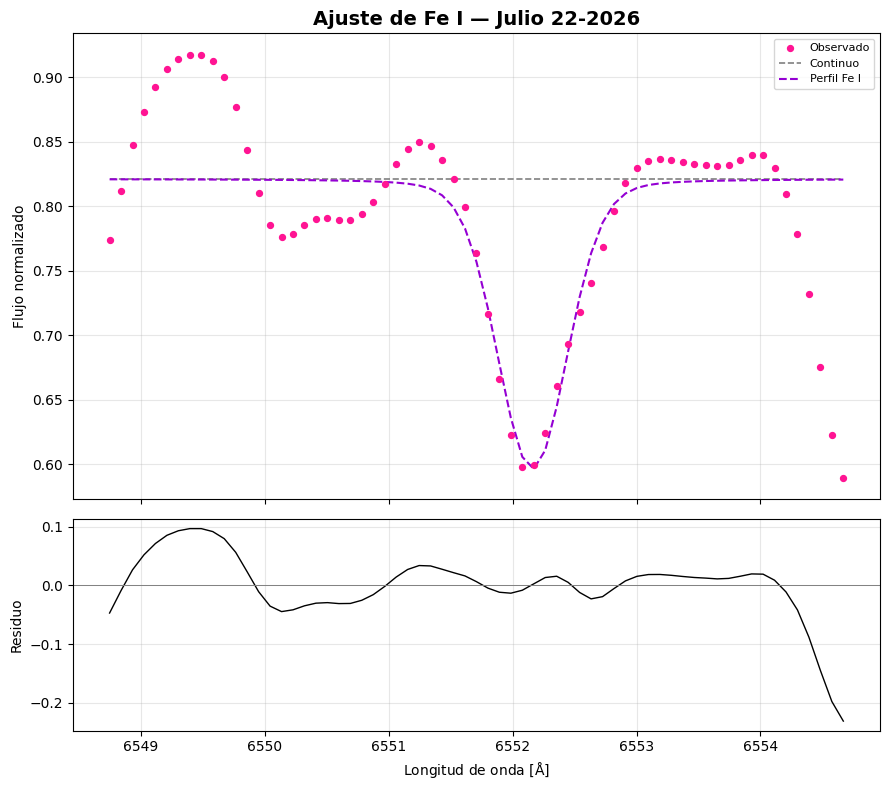

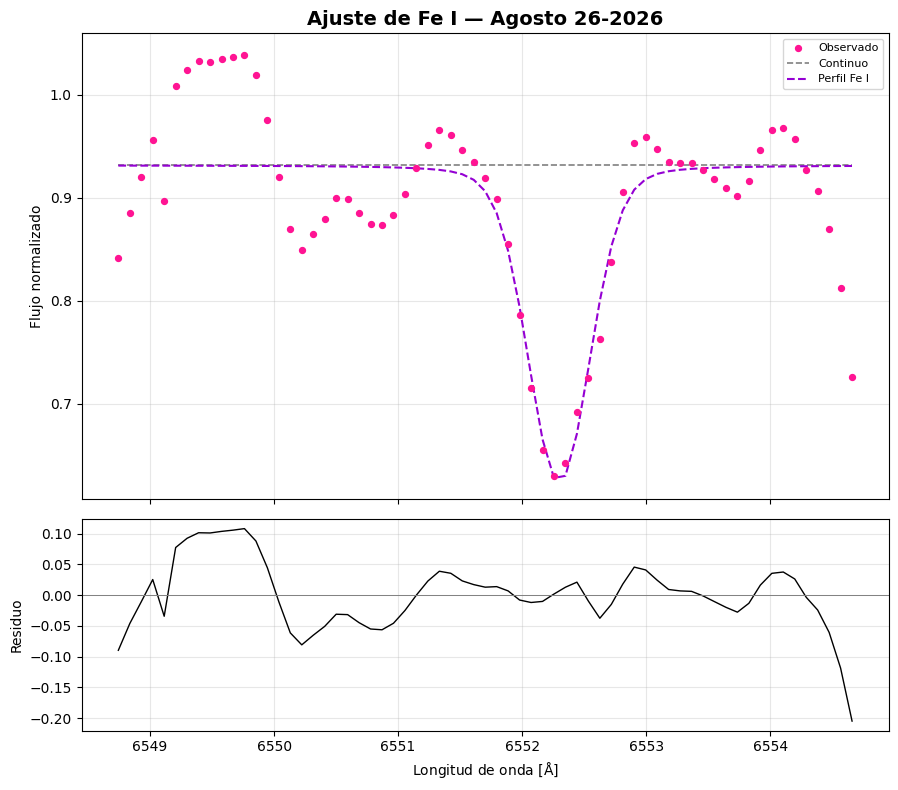

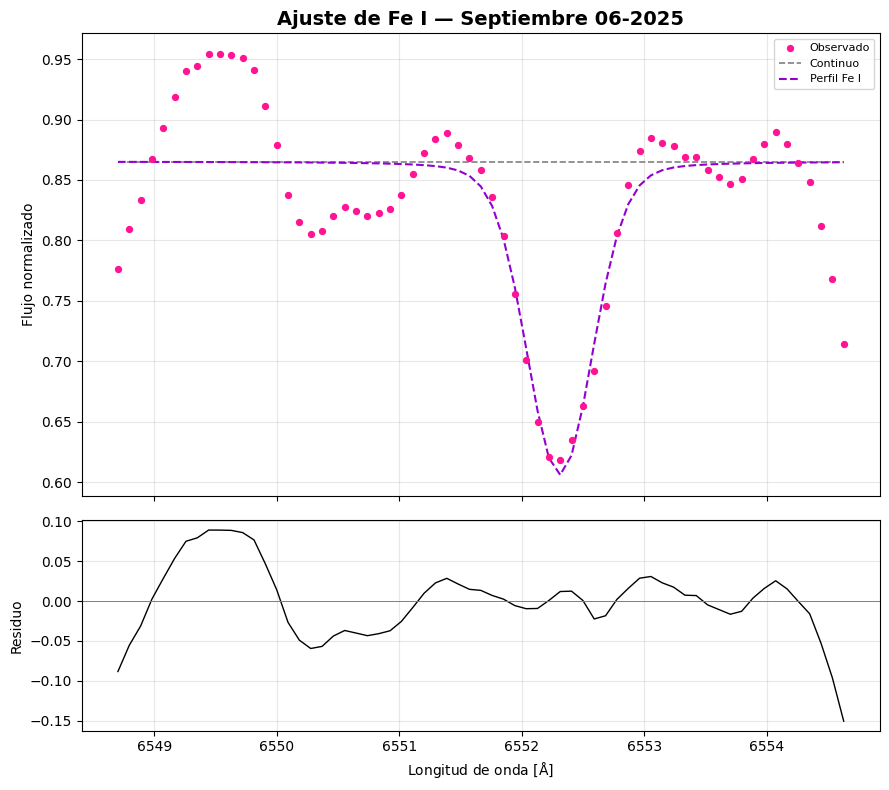

In [ ]:
# for fecha, res_fe in resultados_fe.items():
#     visualizacion_fe(res_fe, fecha)

<h5 style="color: #e19edc;"> Gráfica Conjunta</sub></h5>

In [103]:
def dibujar_fe_en_ax(res_fe, fecha, ax, ax2):

    longitud_onda = res_fe["longitud_onda"]
    flujo = res_fe["flujo"]
    fit = res_fe["fit"]

    comps = fit.eval_components(x=longitud_onda)
    continuo = comps["cont_"]

    perfil_fe = continuo + comps["fe1_"]
    modelo_total = fit.best_fit

    residuo = flujo - modelo_total

    # Panel Superior
    ax.scatter(longitud_onda, flujo, s=18, color="deeppink", label="Observado", zorder=3)
    ax.plot(longitud_onda, continuo, "--", color="gray", lw=1.2, label="Continuo")
    ax.plot(longitud_onda, perfil_fe, "--", color="darkviolet", lw=1.5, label="Perfil Fe I")
    ax.set_ylabel("Flujo normalizado")
    ax.set_title(f"Ajuste de Fe I — {fecha}", fontsize=12, fontweight="bold", pad=6)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Panel Inferior (Residuo)
    ax2.plot(longitud_onda, residuo, color="black", lw=1)
    ax2.axhline(0, color="gray", lw=0.7)
    ax2.set_xlabel(r"Longitud de onda [$\mathrm{\AA}$]")
    ax2.set_ylabel("Residuo")
    ax2.grid(alpha=0.3)

    # Compartir rango de X
    ax2.set_xlim(ax.get_xlim())

In [104]:
def visualizacion_fe(res_fe_dict, carpeta_salida=None, mostrar=True):

    fechas = list(res_fe_dict.keys())

    if len(fechas) == 0:
        return None

    n_filas = int(np.ceil(len(fechas) / 2))

    fig = plt.figure(figsize=(16, 5.5 * n_filas))
    gs = GridSpec(n_filas, 2, figure=fig, hspace=0.45, wspace=0.15)

    for i, fecha in enumerate(fechas):

        fila = i // 2
        columna = i % 2
        es_ultima = (i == len(fechas) - 1)
        es_impar = (len(fechas) % 2 == 1)

        if es_ultima and es_impar:

            gs_centro = gs[fila, :].subgridspec(2, 4, height_ratios=[2.2, 1], hspace=0.05, wspace=0.15)
            subgs = gs_centro[:, 1:3]
            subgs = subgs.subgridspec(2, 1, height_ratios=[2.2, 1], hspace=0.05)

        else:
            subgs = gs[fila, columna].subgridspec(2, 1, height_ratios=[2.2, 1], hspace=0.05)

        ax = fig.add_subplot(subgs[0])
        ax2 = fig.add_subplot(subgs[1], sharex=ax)

        dibujar_fe_en_ax(res_fe_dict[fecha], fecha, ax, ax2)

    fig.suptitle(r"Ajuste de Fe I", fontsize=18, fontweight="bold", y=0.98)
    fig.subplots_adjust(top=0.92, bottom=0.05, left=0.06, right=0.98, hspace=0.45, wspace=0.15)

    if carpeta_salida is not None:
        ruta = (carpeta_salida + r"\comparacion_Fe_I.png")
        fig.savefig(ruta, dpi=300, bbox_inches="tight")
        print(f"Figura de Fe I guardada en:\n{ruta}")

    if mostrar:
        plt.show()

    return fig

Figura de Fe I guardada en:
Graficas 2024, 2025 y 2026\Modelamiento\comparacion_Fe_I.png


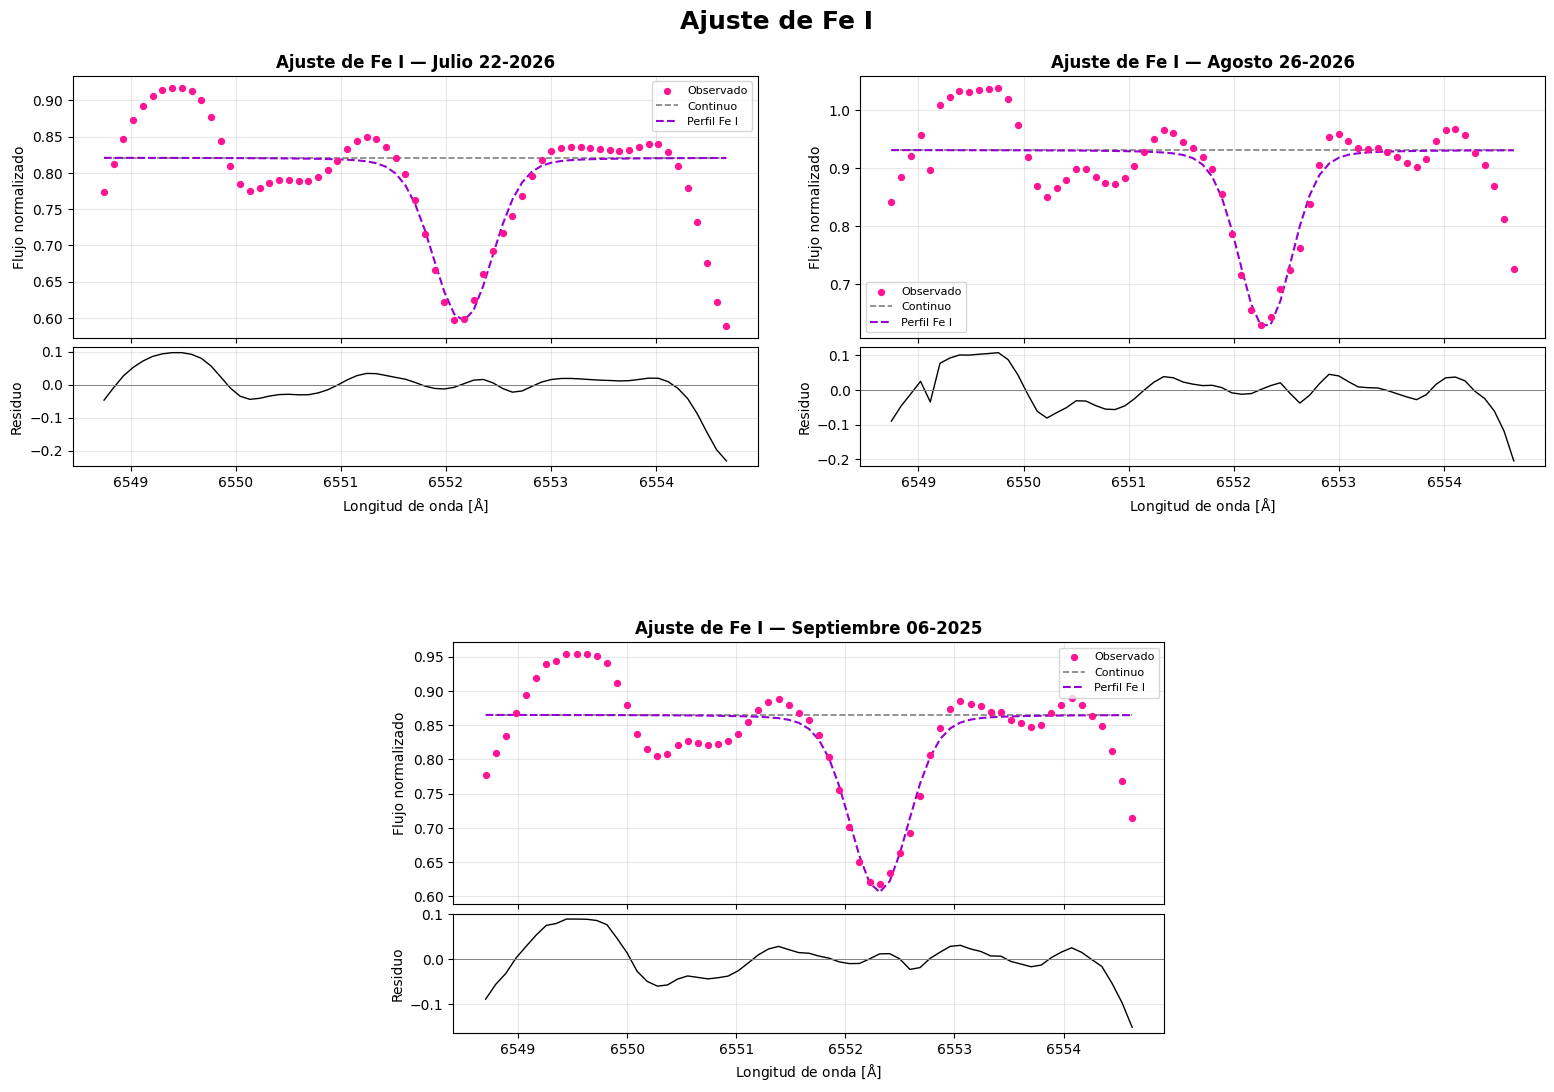

In [108]:
fig = visualizacion_fe(resultados_fe, carpeta_salida=carpeta_salida)

<h4 style="color: #e19edc;"> Resultados de los modelos para su análisis</sub></h4>

In [109]:
print("=" * 95)
print(
    f"{'FECHA':<18} | "
    f"{'PROFUNDIDAD Hα':<20} | "
    f"{'PROFUNDIDAD Co I':<20} | "
    f"{'PROFUNDIDAD Fe I':<20}"
)
print("=" * 95)

for fecha, res in resultados.items():

    fit = res["fit"]
    params = fit.params

    # Profundidades Hα y Co I
    prof_halpha = params["valle_abs_height"].value
    prof_cobalto = params["Cobalto_height"].value

    # Profundidad Fe I
    res_fe = resultados_fe.get(fecha)
    if res_fe is None:
        continue 
    prof_fe = res_fe["profundidad_fit"]
    err_fe = res_fe["profundidad_err"]

    print(
        f"{fecha:<18} | "
        f"{abs(prof_halpha):<20.4f} | "
        f"{abs(prof_cobalto):<20.4f} | "
        f"{prof_fe:<10.4f} ± {err_fe:<7.4f}"
    )

print("=" * 95)

FECHA              | PROFUNDIDAD Hα       | PROFUNDIDAD Co I     | PROFUNDIDAD Fe I    
Septiembre 06-2025 | 0.7306               | 0.4769               | 0.2996     ± 0.0327 
Julio 22-2026      | 0.7635               | 0.4564               | 0.2739     ± 0.0429 
Agosto 26-2026     | 0.8577               | 0.5155               | 0.3304     ± 0.0384 
